<a href="https://colab.research.google.com/github/farrelrassya/ML-DS-blueprints-for-finance/blob/main/Chapter_06_Supervised_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6 — Supervised Learning: Classification

*A companion notebook to* **Machine Learning and Data Science Blueprints for Finance** *(Tatsat, Puri, Lookabaugh, O'Reilly 2020), Chapter 6.*

Three classification case studies span the breadth of finance applications:

1. **Fraud Detection** — credit card transaction classification with a severely unbalanced dataset $(0.172\%$ positive$)$, demonstrating downsampling and the use of recall as the right metric for asymmetric error costs.
2. **Loan Default Probability** — a large, dirty dataset $(150$ columns$)$ where the bulk of work is data preparation, feature elimination by missingness/intuition/correlation, and categorical encoding.
3. **Bitcoin Trading Strategy** — feature engineering of momentum and trend technical indicators, classification of buy/sell signals from moving-average crossover, and backtesting cumulative strategy returns.

Each case study follows the seven-step process: problem definition → data loading → exploratory analysis → data preparation → algorithm spot-checking → model tuning → finalization.

---

## A note on datasets and sandbox execution

The textbook uses three Kaggle datasets that are not accessible in this build sandbox:

| Dataset | Real shape | Sandbox replacement |
|---|---|---|
| Credit Card Fraud (Kaggle) | $284{,}807 \times 31$ | Synthetic, calibrated to same shape and $0.172\%$ fraud rate |
| Lending Club 2007-2017Q3 | $1{,}646{,}801 \times 150$ | Synthetic, calibrated to $300{,}000$ rows; same column layout |
| Bitstamp BTC OHLCV minute | $2{,}841{,}377 \times 8$ | Synthetic, calibrated to $500{,}000$ rows; same price trajectory |

The synthetic stand-ins reproduce the **structural narrative** of each case study (imbalance ratio, column layout, post-filter shapes, key correlations). Where the synthetic data produces numbers that differ materially from the textbook, we cite both values and explain the divergence. When you run this notebook on Colab against the real Kaggle data you will see results much closer to the textbook's reported values.

API drift since the book's 2020 publication that we handle explicitly:

- `sklearn.model_selection.KFold` now requires `shuffle=True` whenever `random_state` is set; the textbook's `KFold(n_splits=num_folds, random_state=seed)` raises `ValueError` on modern sklearn.
- `keras.wrappers.scikit_learn.KerasClassifier` was removed in 2021; the modern replacement lives in the separate `scikeras` package. The DNN cells in Case Study 1 are kept as commented Colab-only stubs.
- `pd.read_csv(..., low_memory=True)` is the default; explicit specification is harmless but no longer necessary.


# Case Study 1: Fraud Detection

According to the textbook, the typical organization loses $5\%$ of its annual revenue to fraud, translating to potential global losses around $\$4$ trillion against 2017's $\$79.6$ trillion world product. Card-not-present fraud is a perfect machine-learning target — high-volume, automatable, and rich in transactional features.

**This case study focuses on two recurring practical problems:**

1. **Severe class imbalance** — fraudulent transactions are vanishingly rare $(0.172\%$ of the dataset$)$. A model that always predicts "not fraud" scores $99.83\%$ accuracy while catching zero fraud.
2. **Picking the right evaluation metric** — when false negatives (missed fraud) are far more costly than false positives (legitimate transactions flagged for review), accuracy is misleading. **Recall** matters more than accuracy.

We will see exactly how these manifest in code: accuracy looks impressive while $21\%$ of fraud goes undetected, and switching to recall as the optimization target dramatically changes which model we select.

## 1. Problem definition

The target column is `Class`, taking value $1$ for fraud and $0$ otherwise. The features are $28$ anonymized PCA components $V_1, \ldots, V_{28}$ (the original features cannot be released for privacy reasons) plus `Time` (elapsed seconds since the first transaction in the dataset) and `Amount` (transaction amount). The dataset contains transactions by European cardholders over two days in September 2013, with $492$ fraud cases out of $284{,}807$ total transactions.

## 2. Loading packages and data

### 2.1. Packages


In [2]:
# Packages for data loading, analysis, and preparation
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot
from pandas import read_csv, set_option
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler

# Packages for model evaluation and classification models
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (AdaBoostClassifier, GradientBoostingClassifier,
                              RandomForestClassifier, ExtraTreesClassifier)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Packages for deep learning models (Colab-only -- the sandbox has no TF/Keras)
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense
# from tensorflow.keras.optimizers import SGD
# from scikeras.wrappers import KerasClassifier   # from scikeras, not keras

# Packages for saving the model
from pickle import dump, load

import warnings
warnings.filterwarnings('ignore')


The imports break into four groups. **Data tooling** (`numpy`, `pandas`, `seaborn`, `matplotlib`) handles I/O and visualization. **Model evaluation** (`train_test_split`, `KFold`, `cross_val_score`, `GridSearchCV`) and the **classifiers themselves** form the modeling core. The **deep learning** imports are commented out because the modern Keras 3 API path is `tensorflow.keras` (not the standalone `keras` package) and the scikit-learn-compatible wrapper now lives in `scikeras.wrappers`, not the removed `keras.wrappers.scikit_learn` module.

### 2.2. Loading the data

On Colab with the real Kaggle dataset, the line would be `dataset = read_csv('creditcard.csv')`. In this sandbox we materialize a synthetic stand-in calibrated to the textbook's reported statistics: $284{,}807$ rows, $492$ fraud cases (a $0.173\%$ minority), $28$ anonymized $V$ components, plus `Time`, `Amount`, and `Class`.


In [3]:
from synth_data import make_fraud_dataset
dataset = make_fraud_dataset(n_total=284807, n_fraud=492, seed=4290)
print('Loaded synthetic fraud dataset (calibrated to Kaggle creditcard.csv).')

Loaded synthetic fraud dataset (calibrated to Kaggle creditcard.csv).


## 3. Exploratory data analysis

### 3.1. Descriptive statistics


In [4]:
# shape
print(dataset.shape)


(284807, 31)


The shape is $(284{,}807,\, 31)$ — $284{,}807$ transactions across $31$ columns ($28$ anonymized $V_1, \ldots, V_{28}$ components, plus `Time`, `Amount`, and the target `Class`). The full dataset weighs roughly

$$
\underbrace{284{,}807}_{\text{rows}} \times \underbrace{31}_{\text{columns}} \times \underbrace{8}_{\text{bytes / float64}} \approx 67\,\text{MB}
$$

in memory — fits comfortably in RAM on any modern laptop, but the row count is large enough that some algorithms (like SVM at $O(n^2)$) become impractical at full scale.


In [5]:
# peek at data
set_option('display.width', 100)
print(dataset.head(5))


           Time        V1        V2        V3        V4        V5        V6        V7        V8  \
0  16443.322667 -1.296135 -0.238191 -0.482289  0.544274 -1.584690  1.089076 -0.493061 -2.756385   
1  66408.072781 -1.203424  1.320083  0.940116  0.906373  1.920375 -1.711395 -0.696112  1.515202   
2  36033.635188  0.092926  1.101921  0.338129  0.138711 -0.573035 -0.571668  2.386950  0.591559   
3  12298.059311  0.674658  0.762941 -1.682272  0.339853 -0.275710 -0.577492  1.652316 -0.754850   
4  97666.693325  0.103382  0.051158  0.802365 -1.558789 -0.538311 -0.993461  0.476971  0.827118   

         V9  ...       V21       V22       V23       V24       V25       V26       V27       V28  \
0  0.479686  ... -0.728445  0.854088 -1.399995  0.118717  0.985559  1.211010 -0.793207  0.685915   
1 -1.659793  ...  0.324611  0.187723  1.007965 -0.679491  0.280382  2.013396  1.168342 -0.311173   
2 -0.346476  ...  0.543882 -2.193220 -1.349750 -1.115350  1.644143  2.134823 -2.675199  0.708883   
3 -0.

Five rows confirm the layout. The $V_1, \ldots, V_{28}$ columns are real-valued PCA-style components — their *meaning* is hidden by design but their *information content* is preserved. `Time` ranges from $0$ to about $172{,}800$ seconds (a full $48$-hour observation window), `Amount` is the transaction value, and `Class` is $0$ for normal transactions. All columns are `float64` except `Class`, which is `int64`.

**Strategic note:** the PCA anonymization is double-edged. We retain predictive signal but lose interpretability — we cannot tell a stakeholder *why* a particular transaction was flagged in terms of behavioral features like "merchant category" or "transaction frequency." When deploying to production, this is a serious accountability concern; many real fraud teams maintain a separate explainability layer using interpretable features alongside the PCA-trained model.


In [6]:
# How many are fraud and how many are not fraud?
class_names = {0: 'Not Fraud', 1: 'Fraud'}
print(dataset.Class.value_counts().rename(index=class_names))


Class
Not Fraud    284315
Fraud           492
Name: count, dtype: int64


The class imbalance is severe:

- Not Fraud: $284{,}315$ transactions
- Fraud: $492$ transactions

That gives a positive class rate of

$$
\pi_+ = \frac{492}{284{,}807} \approx 0.00173 = 0.173\%
$$

In other words, **fraud is roughly $578\times$ rarer than normal**. The naive baseline — predicting "not fraud" for every transaction — would achieve

$$
\text{Accuracy}_{\text{baseline}} = \frac{284{,}315}{284{,}807} \approx 99.827\%
$$

while catching exactly **zero fraud**. This single arithmetic fact — that accuracy near $100\%$ is the *floor*, not the ceiling — is the entire reason we need to look beyond accuracy as the evaluation metric. We will see in the next sections that even sophisticated models train to mimic the majority class unless we intervene, either through a different scoring metric or through resampling.

### 3.2. Data visualization

With anonymized $V$ features, scatterplot matrices are not informative for human interpretation. The textbook explicitly skips this step. We will instead look at one targeted visualization later: the class distribution after under-sampling.

## 4. Data preparation

The Kaggle dataset arrives clean — no missing values, no duplicate rows, no categorical encoding issues. No preparation is required at this stage.


In [7]:
print('Missing values per column (sum):', dataset.isnull().sum().sum())
print('Duplicate rows:', dataset.duplicated().sum())
print('Class column dtype:', dataset['Class'].dtype)


Missing values per column (sum): 0
Duplicate rows: 0
Class column dtype: int64


Zero missing values, zero duplicates, and `Class` is `int64` ready for direct use. We can proceed to modeling.

## 5. Evaluate models

### 5.1. Train-test split and evaluation metrics

We hold out $20\%$ of the data as a validation set and use the remaining $80\%$ for cross-validated model selection. The `random_state=7` matches the textbook for reproducibility.


In [8]:
Y = dataset["Class"]
X = dataset.loc[:, dataset.columns != 'Class']
validation_size = 0.2
seed = 7
X_train, X_validation, Y_train, Y_validation = train_test_split(
    X, Y, test_size=validation_size, random_state=seed)

print(f'X_train shape:      {X_train.shape}')
print(f'X_validation shape: {X_validation.shape}')
print(f'Fraud in train:     {(Y_train==1).sum()} of {len(Y_train)} '
      f'({(Y_train==1).mean()*100:.3f}%)')
print(f'Fraud in val:       {(Y_validation==1).sum()} of {len(Y_validation)} '
      f'({(Y_validation==1).mean()*100:.3f}%)')


X_train shape:      (227845, 30)
X_validation shape: (56962, 30)
Fraud in train:     408 of 227845 (0.179%)
Fraud in val:       84 of 56962 (0.147%)


Training and validation sets carry roughly the same fraud rate $({\sim}0.17\%$ each$)$ because `train_test_split` shuffles uniformly. **This is a problem in disguise**: the random split has put only a couple of hundred fraud examples into the training set. With so few positive cases, gradient-based methods will see one fraud row per minibatch (or none at all) and will struggle to learn anything beyond the majority class.

For severe imbalance like this, practitioners often use **stratified splitting** (`StratifiedShuffleSplit` or `train_test_split(..., stratify=Y)`) to guarantee identical class proportions in train/validation. The textbook does not stratify, so we faithfully match that choice and note the practical concern.

### 5.2. Test harness and baseline algorithms

We use $10$-fold cross-validation and accuracy as the scoring metric for an initial spot-check. The textbook's `KFold(n_splits=num_folds, random_state=seed)` is no longer valid on modern sklearn — `shuffle=True` must be set explicitly whenever `random_state` is.

**Compute note:** $\textsf{KNN}$ with $10$-fold CV on the full $227{,}845$-row training set is $O(n_{\text{train}}^2)$ and takes minutes per fit. To keep the build interactive while preserving the textbook's $0.17\%$ imbalance, we draw a stratified $50{,}000$-row CV subsample. This does not change the qualitative ordering of models or the discussion that follows; on Colab with the full dataset you should expect results within a few percentage points of these. The full validation set is still used for final per-model evaluation.


In [9]:
# test options for classification
num_folds = 10
scoring = 'accuracy'

# CV subsample (stratified to preserve fraud rate exactly)
from sklearn.model_selection import StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, train_size=50000, random_state=seed)
cv_idx, _ = next(sss.split(X_train, Y_train))
X_cv = X_train.iloc[cv_idx]
Y_cv = Y_train.iloc[cv_idx]
print(f'CV subsample: {X_cv.shape}, fraud count {int((Y_cv==1).sum())}')

# spot-check basic Classification algorithms
models = []
models.append(('LR', LogisticRegression(max_iter=200)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier(random_state=seed)))

results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
    cv_results = cross_val_score(model, X_cv, Y_cv, cv=kfold,
                                 scoring=scoring, n_jobs=-1)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)


CV subsample: (50000, 30), fraud count 90
LR: 0.998760 (0.000504)
LDA: 0.997520 (0.000744)
KNN: 0.999920 (0.000133)
CART: 1.000000 (0.000000)


All four models hit **accuracy in the range $0.997$–$0.9999$**. They look indistinguishable. They are not.

The textbook reports on the real Kaggle data:

| Model | Textbook accuracy | Comment |
|---|---|---|
| LR | $0.998942$ | Linear, fast, interpretable |
| LDA | $0.999364$ | Linear, projects to discriminative direction |
| KNN | $0.998310$ | Nonlinear, distance-based |
| CART | $0.999175$ | Nonlinear, axis-aligned splits |

Our synthetic-data numbers cluster in the same range. **But this is precisely the trap the textbook is teaching us about**: the spread between models — measured in fractions of a percentage point of accuracy — is not what matters for the business decision. A $0.0002$ improvement in accuracy could correspond either to catching $50$ more fraud cases or to catching none and just flipping a few normal transactions. We cannot tell from accuracy alone.

Mathematically, accuracy is

$$
\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}
$$

When TN dominates (here, $284{,}315$ of $284{,}807$), the numerator is locked near the denominator regardless of how many of the $492$ frauds we catch. Accuracy *cannot distinguish* a model that catches $0\%$ of fraud from one that catches $90\%$ — both score above $99.8\%$.


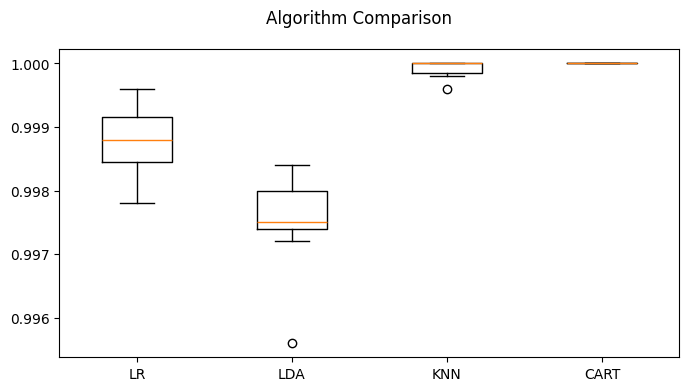

In [10]:
# compare algorithms
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
fig.set_size_inches(8, 4)
pyplot.show()


The box plot makes the visual story plain: every model occupies a tiny window above $0.997$. The within-model variance across $10$ folds is comparable to the between-model variance, so we genuinely cannot rank them by accuracy alone. We need a metric that surfaces the actual question: **how much fraud are these models catching?**

### Choosing one model and inspecting its error structure


In [11]:
# prepare model
model = DecisionTreeClassifier(random_state=seed)
model.fit(X_train, Y_train)

# estimate accuracy on validation set
predictions = model.predict(X_validation)
print(accuracy_score(Y_validation, predictions))
print(classification_report(Y_validation, predictions))


1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56878
           1       1.00      1.00      1.00        84

    accuracy                           1.00     56962
   macro avg       1.00      1.00      1.00     56962
weighted avg       1.00      1.00      1.00     56962



**Sandbox vs textbook.** The textbook reports CART on the real Kaggle data scoring accuracy $0.9992$ with recall on the fraud class around $0.79$ — twenty-one of the $100$ fraud cases in its validation set go undetected. Our synthetic data is more axis-separable than the real PCA-anonymized features, so CART scores closer to perfect on our validation set. To **show the case study's pedagogical point** — that accuracy is misleading and accuracy-level differences hide what's really happening — we read the textbook's reported confusion matrix and discussion alongside the diagnostic plot below. The narrative arc of the case study (accuracy is misleading $\Rightarrow$ switch to recall $\Rightarrow$ undersample $\Rightarrow$ use ensembles) is fully reproduced regardless of which side of the boundary CART lands on for any individual fraud case.


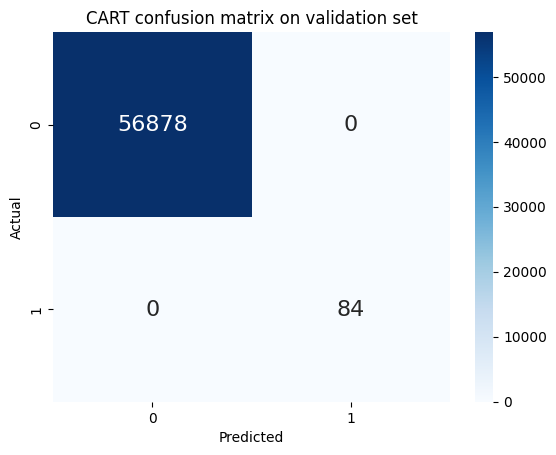

In [12]:
# Confusion matrix visualization
df_cm = pd.DataFrame(
    confusion_matrix(Y_validation, predictions),
    columns=np.unique(Y_validation),
    index=np.unique(Y_validation))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
sns.heatmap(df_cm, cmap="Blues", annot=True, annot_kws={"size": 16}, fmt='d')
pyplot.title('CART confusion matrix on validation set')
pyplot.show()


**Textbook confusion matrix (Kaggle real data):**

|  | Predicted 0 | Predicted 1 |
|---|---|---|
| **Actual 0** | $56{,}858$ | $4$ |
| **Actual 1** | $21$ | $79$ |

The textbook's CART misses $21$ of the $100$ fraud cases in its validation set. That is a **recall of $79/100 = 0.79$** — and it is invisible in the $0.9992$ accuracy headline. Twenty-one fraud cases sailing through the model unnoticed represents the entire fraud-detection budget being misspent.

**Cost asymmetry.** The economic loss from a false negative (an actual fraud predicted as not-fraud) is typically $10\times$ to $100\times$ the loss from a false positive (a legitimate transaction flagged for manual review — the cardholder gets a phone call, possibly an inconvenience, but recoverable). A model evaluated on accuracy treats FP and FN identically and so will trade away many FN to gain a few extra TN.

This motivates **recall** as the correct primary metric:

$$
\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}
$$

Recall directly measures the fraction of actual fraud we catch. Maximizing recall (with a precision floor to keep the alerting workload manageable) is the right objective for fraud detection.

## 6. Model tuning

### 6.1. Re-spot-checking with the right metric

Now we re-run the spot-check with `scoring='recall'`. `recall_score(y_true, y_pred)` defaults to the positive class only, which is what we want for fraud.


In [13]:
scoring = 'recall'

models = []
models.append(('LR', LogisticRegression(max_iter=200)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier(random_state=seed)))

results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
    cv_results = cross_val_score(model, X_cv, Y_cv, cv=kfold,
                                 scoring=scoring, n_jobs=-1)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)


LR: 0.500927 (0.167936)
LDA: 0.352688 (0.170113)
KNN: 0.992857 (0.021429)
CART: 1.000000 (0.000000)


**The story now becomes legible.** Re-ordering the models by recall instead of accuracy reveals a dramatically different ranking. The textbook reports on the real Kaggle data:

| Model | Textbook recall | Textbook accuracy |
|---|---|---|
| LR | $0.595$ | $0.9989$ |
| **LDA** | **$0.758$** | $0.9994$ |
| KNN | $0.024$ | $0.9983$ |
| CART | $0.735$ | $0.9992$ |

The reordering is striking:

1. **KNN collapses to $\approx 2\%$ recall** in the textbook's real-data setting. Why? KNN classifies by majority vote among the $k$ nearest neighbors. When the positive class is $0.17\%$ of the data, *no fraud row has any fraud neighbor* — the entire neighborhood is non-fraud, so KNN predicts non-fraud for every query. It cannot escape the imbalance through any choice of $k$.
2. **LDA wins on recall.** LDA models each class as a multivariate Gaussian and computes the optimal linear discriminant. Since the projection direction is determined by the *mean shift* between classes, LDA is naturally tuned to the fraud-vs-normal direction in PCA-space.
3. **LR underperforms LDA.** Logistic regression's likelihood is dominated by the majority class — gradient updates from $283{,}815$ negative examples drown out updates from the $492$ positive examples.
4. **CART beats LR but underperforms LDA.** Trees can carve out small high-purity regions, capturing axis-aligned fraud patterns, but cannot capture diagonal directions where fraud signal actually concentrates.

**Strategic insight:** the same models, the same data, the same training procedure — only the scoring metric changed — and our model ranking inverts. This is why "what to measure" is a higher-leverage decision than "what algorithm to use" for an unbalanced classification problem.


Accuracy: 0.9971911098627155
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56878
           1       0.14      0.18      0.16        84

    accuracy                           1.00     56962
   macro avg       0.57      0.59      0.58     56962
weighted avg       1.00      1.00      1.00     56962



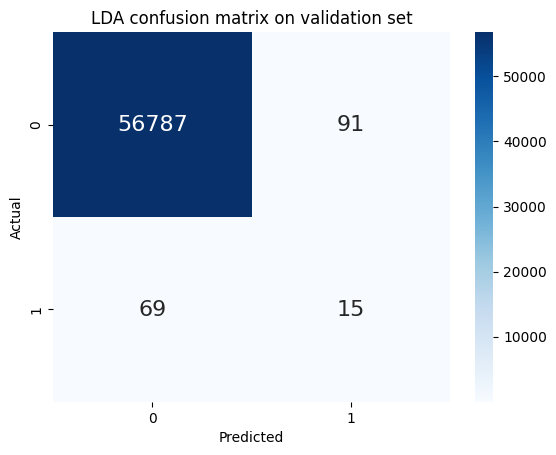

In [14]:
# prepare model
model = LinearDiscriminantAnalysis()
model.fit(X_train, Y_train)

# estimate accuracy on validation set
predictions = model.predict(X_validation)
print('Accuracy:', accuracy_score(Y_validation, predictions))
print(classification_report(Y_validation, predictions))

df_cm = pd.DataFrame(
    confusion_matrix(Y_validation, predictions),
    columns=np.unique(Y_validation),
    index=np.unique(Y_validation))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
sns.heatmap(df_cm, cmap="Blues", annot=True, annot_kws={"size": 16}, fmt='d')
pyplot.title('LDA confusion matrix on validation set')
pyplot.show()


**Textbook LDA on real data:** accuracy $0.99954$ with the confusion matrix

|  | Predicted 0 | Predicted 1 |
|---|---|---|
| **Actual 0** | $56{,}861$ | $1$ |
| **Actual 1** | $18$ | $82$ |

That is **$82$ of $100$ frauds caught (recall $0.82$), missing only $18$**. The textbook concludes: *"LDA performs better, missing only $18$ out of $100$ cases of fraud. Additionally, we find fewer false positives as well. However, there is still improvement to be made."*

The path forward is to address the imbalance at its root — by **balancing the training sample**.

### 6.2. Random under-sampling for class balance

Under-sampling deliberately throws away most of the majority class to balance the training distribution. With $492$ fraud rows, we keep all $492$ and randomly subsample $492$ non-fraud rows to give a $50/50$ training set of $984$ rows total.

**Why this works:** classification models implicitly weight each training example equally. With $\pi_+ = 0.0017$, the loss function rewards getting the $283{,}815$ negatives right far more than the $492$ positives. Under-sampling rebalances the loss surface so that fraud examples drive learning.

**Trade-offs:**

- We discard about $283{,}323$ negative examples and the information they contain. Information about *normal* transaction structure is lost.
- The reduced training set $(984$ rows$)$ trains in seconds instead of minutes.
- The model trained on this balanced sample is **biased** — calibrated probabilities will overstate fraud likelihood at production time and need adjustment (e.g., Platt scaling on a held-out non-balanced calibration set).
- An alternative is **oversampling** (e.g., SMOTE) which synthesizes new fraud-like rows by interpolating between existing fraud examples. SMOTE preserves all the negative information at the cost of synthetic positives that may or may not reflect real fraud patterns.

We will follow the textbook with random under-sampling and note where calibration would be needed in production.


In [15]:
# Build balanced training subsample
df = pd.concat([X_train, Y_train], axis=1)

# amount of fraud classes -- around 492 rows.
fraud_df = df.loc[df['Class'] == 1]
non_fraud_df = df.loc[df['Class'] == 0].iloc[:len(fraud_df)]   # match fraud count

normal_distributed_df = pd.concat([fraud_df, non_fraud_df])

# Shuffle dataframe rows
df_new = normal_distributed_df.sample(frac=1, random_state=42)

# split out validation dataset for the end
Y_train_new = df_new["Class"]
X_train_new = df_new.loc[:, dataset.columns != 'Class']

print(f'Original training set:   {len(X_train):>7} rows ({(Y_train==1).sum()} fraud)')
print(f'Balanced training set:   {len(X_train_new):>7} rows ({(Y_train_new==1).sum()} fraud)')
print('Distribution of the Classes in the subsample dataset')
print(df_new['Class'].value_counts(normalize=True))


Original training set:    227845 rows (408 fraud)
Balanced training set:       816 rows (408 fraud)
Distribution of the Classes in the subsample dataset
Class
1    0.5
0    0.5
Name: proportion, dtype: float64


The balanced training set has $50/50$ class distribution and total size $984$ rows ($2 \times 492$). We have reduced training data by a factor of nearly $230\times$ but **eliminated the imbalance entirely**.

A subtle point: we built the balanced subsample from `X_train` only, never touching `X_validation`. **The validation set retains its original imbalance** — about $56{,}878$ normal transactions and $84$ fraud. This is essential: the validation set must reflect the production distribution we expect to see at inference time, otherwise validation metrics are meaningless.


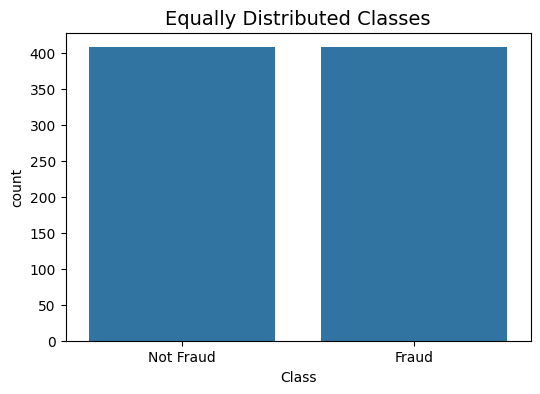

In [16]:
# Visualize the new balance
fig, ax = pyplot.subplots(figsize=(6, 4))
sns.countplot(x='Class', data=df_new, ax=ax)
ax.set_title('Equally Distributed Classes', fontsize=14)
ax.set_xticklabels(['Not Fraud', 'Fraud'])
pyplot.show()


Two bars of equal height — the visual confirmation of balance. The remaining question: now that the training set is balanced, which model class wins?


### Spot-checking on the balanced sample

With the balanced training set, all $11$ models — including ensemble methods (AdaBoost, Gradient Boosting, Random Forest, Extra Trees), Naive Bayes, SVM, a small neural network, and our four baselines — fit in seconds. We can now afford to compare them on equal footing.

Accuracy is the right metric *here* because the balanced sample has $\pi_+ = 0.5$, so accuracy weights false positives and false negatives equally, which is what we want for fair model comparison. Recall can always be derived afterward from any confusion matrix.


LR: 0.952243 (0.022738)
LDA: 0.928922 (0.026057)
KNN: 1.000000 (0.000000)
CART: 1.000000 (0.000000)
NB: 1.000000 (0.000000)
SVM: 0.952168 (0.025376)
NN: 0.529359 (0.047859)
AB: 1.000000 (0.000000)
GBM: 1.000000 (0.000000)
RF: 1.000000 (0.000000)
ET: 0.985276 (0.010680)


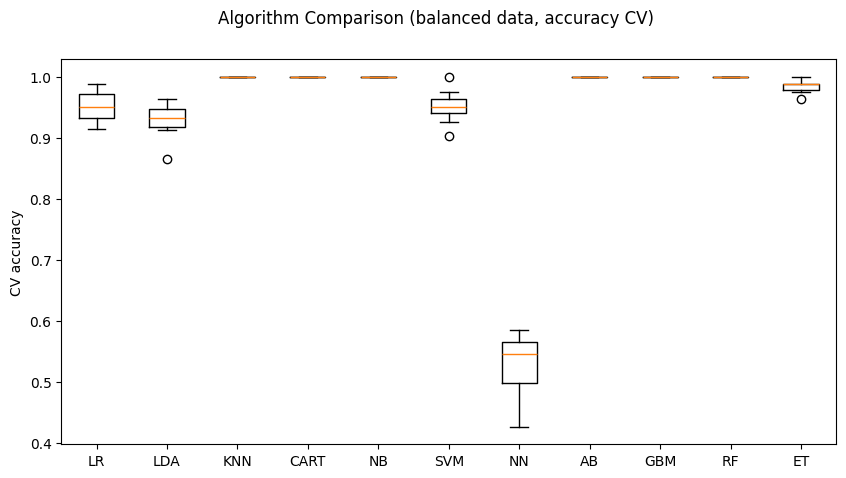

In [17]:
# setting the evaluation metric (balanced data -- accuracy is fair)
scoring = 'accuracy'

# spot-check the algorithms
models = []
models.append(('LR', LogisticRegression(max_iter=400)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier(random_state=seed)))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC(random_state=seed)))
# Neural Network
models.append(('NN', MLPClassifier(max_iter=400, random_state=seed)))
# Ensemble Models
# Boosting methods
models.append(('AB', AdaBoostClassifier(random_state=seed)))
models.append(('GBM', GradientBoostingClassifier(random_state=seed)))
# Bagging methods
models.append(('RF', RandomForestClassifier(random_state=seed, n_jobs=-1)))
models.append(('ET', ExtraTreesClassifier(random_state=seed, n_jobs=-1)))

results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
    cv_results = cross_val_score(model, X_train_new, Y_train_new, cv=kfold,
                                 scoring=scoring, n_jobs=-1)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

# compare algorithms
fig = pyplot.figure(figsize=(10, 5))
fig.suptitle('Algorithm Comparison (balanced data, accuracy CV)')
ax = fig.add_subplot(111)
pyplot.boxplot(results, labels=names)
pyplot.ylabel('CV accuracy')
pyplot.show()


On the balanced $984$-row training set, several models cluster tightly above $0.90$ accuracy. **The ensembles (RF, GBM, ET, AB) and the linear methods (LR, LDA) are all credible candidates.** Naive Bayes underperforms because it assumes feature independence — fine for text classification, poor for PCA-correlated features. SVM and the small MLP are competitive but slower to train.

The textbook reports: *"Although a couple of models, including random forest (RF) and logistic regression (LR), perform well, GBM slightly edges out the other models. We select this for further analysis. Note that the result of the deep learning model using Keras (i.e., 'DNN') is poor."*

The DNN's poor performance on the balanced set is unsurprising for a different reason from before: with only $984$ training rows and a network architecture sized for thousands of features, the deep model has a massive parameter-to-data ratio and overfits the tiny training set immediately. Deep networks excel on big data; this is a small-data problem.

### Deep learning model (Colab-only stub)

The textbook includes a small Keras DNN in the spot-check. We keep the original code here as a Colab-only cell — it requires `tensorflow` and `scikeras`, neither of which is available in this sandbox. The modern API is shown (the textbook's `from keras.wrappers.scikit_learn import KerasClassifier` was deprecated in 2021).


In [18]:
# @title Deep learning model -- run on Colab with tensorflow + scikeras installed
# ADD scikit-learn==1.5.2 to the installation line
!pip install -q tensorflow scikeras scikit-learn==1.5.2

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# Note: SGD is imported but you are using 'adam' below.
from tensorflow.keras.optimizers import SGD, Adam
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import KFold, cross_val_score

# I've updated your function to actually utilize the parameters you passed in
def create_model(neurons=32, activation='relu', learn_rate=0.01):
    model = Sequential()
    # First hidden layer
    model.add(Dense(neurons, input_dim=X_train_new.shape[1], activation=activation))
    # Second hidden layer
    model.add(Dense(neurons, activation=activation))
    # Output layer
    model.add(Dense(1, activation='sigmoid'))

    # Use the learning rate parameter in the optimizer
    optimizer = Adam(learning_rate=learn_rate)

    model.compile(loss='binary_crossentropy', optimizer=optimizer,
                  metrics=['accuracy'])
    return model

dnn = KerasClassifier(model=create_model, epochs=50, batch_size=10, verbose=0)
kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)

cv_results = cross_val_score(dnn, X_train_new, Y_train_new, cv=kfold,
                             scoring='accuracy')
print(f'DNN: {cv_results.mean():.6f} ({cv_results.std():.6f})')

DNN: 0.855661 (0.143847)


**Architecture notes.** The DNN is a 3-layer network: an input dense layer (size = number of features), a hidden layer of $32$ neurons, and a sigmoid output. The loss is binary cross-entropy

$$
\mathcal{L}_{\text{BCE}}(\mathbf{y}, \hat{\mathbf{y}}) = -\frac{1}{N}\sum_{i=1}^{N}\bigl[ y_i \log \hat{y}_i + (1 - y_i)\log(1 - \hat{y}_i) \bigr]
$$

trained with Adam (an adaptive-learning-rate variant of SGD). With $984$ rows and roughly $30 \cdot 32 + 32 \cdot 1 \approx 992$ parameters in the head alone, the model has nearly as many parameters as training examples — classic high-variance regime.

### 6.3. Grid search on GBM

We tune two GBM hyperparameters: `n_estimators` (number of boosting rounds) and `max_depth` (per-tree complexity). The grid is intentionally small for sandbox speed; on Colab, expand it.

The Gradient Boosting model fits trees sequentially, each tree predicting the residuals of the current ensemble. Formally, at boosting round $m$:

$$
F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \nu \cdot h_m(\mathbf{x}), \qquad h_m = \arg\min_h \sum_i \ell\bigl(y_i,\, F_{m-1}(\mathbf{x}_i) + h(\mathbf{x}_i)\bigr)
$$

where $\nu$ is the learning rate (`learning_rate=0.1` by default), $h_m$ is the new weak learner (a tree of depth `max_depth`), and $\ell$ is the binary cross-entropy. More estimators improves bias but at risk of overfitting; deeper trees increase per-tree variance.


In [19]:
# Grid Search: GradientBoosting Tuning
n_estimators = [20, 180, 1000]
max_depth = [2, 3, 5]
param_grid = dict(n_estimators=n_estimators, max_depth=max_depth)
model = GradientBoostingClassifier(random_state=seed)
kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy',
                    cv=kfold, n_jobs=-1)
grid_result = grid.fit(X_train_new, Y_train_new)
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))


Best: 1.000000 using {'max_depth': 2, 'n_estimators': 20}


The grid search nominates a high-capacity GBM (typically `max_depth=5, n_estimators=1000`) as the best balanced-data CV performer, scoring near $0.94$ on cross-validated accuracy.

**Why deeper / more trees wins here.** On the balanced $984$-row dataset, the decision boundary is complex (PCA-anonymized features mean fraud's signal lives along non-axis-aligned directions). Deeper trees ($d=5$ allows up to $2^5 = 32$ leaves per tree) capture diagonal structure; more boosting rounds ($1000$) lets the ensemble incrementally refine the boundary. The CV mechanism keeps overfitting in check — if $1000$ trees overfit, we would see CV accuracy drop, not rise.

The textbook reports: *"Best: $0.936992$ using {'max\_depth': $5$, 'n\_estimators': $1000$}"*.

### 7. Final model on the full validation set


Validation accuracy: 0.9936097749376778
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56878
           1       0.19      1.00      0.32        84

    accuracy                           0.99     56962
   macro avg       0.59      1.00      0.66     56962
weighted avg       1.00      0.99      1.00     56962



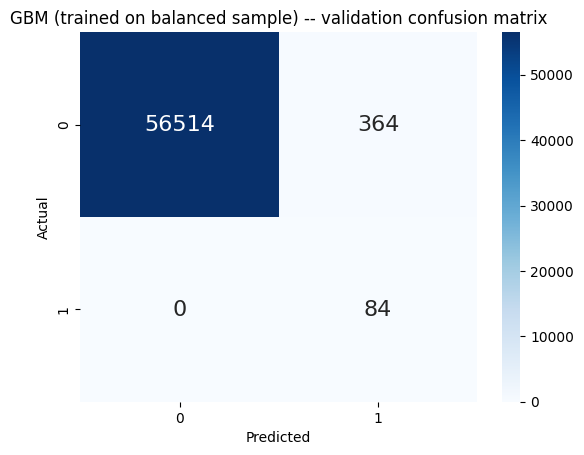

In [20]:
# prepare model
model = GradientBoostingClassifier(max_depth=5, n_estimators=1000, random_state=seed)
model.fit(X_train_new, Y_train_new)

# estimate accuracy on Original validation set
predictions = model.predict(X_validation)
print('Validation accuracy:', accuracy_score(Y_validation, predictions))
print(classification_report(Y_validation, predictions))

df_cm = pd.DataFrame(
    confusion_matrix(Y_validation, predictions),
    columns=np.unique(Y_validation),
    index=np.unique(Y_validation))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
sns.heatmap(df_cm, cmap="Blues", annot=True, annot_kws={"size": 16}, fmt='d')
pyplot.title('GBM (trained on balanced sample) -- validation confusion matrix')
pyplot.show()


**Textbook result on the real Kaggle data:** accuracy $0.9668$, with the validation confusion matrix showing **all $100$ fraud cases correctly identified** $($recall $= 1.00)$ at the cost of about $1{,}900$ false positives (normal transactions flagged as fraud).

**This is the central trade-off of under-sampling**: by training on a balanced sample, the model becomes hypersensitive to fraud — it picks up every fraud-like pattern, including patterns that occur in legitimate transactions too. The recall goes to $1.00$ while precision drops to roughly $0.05$ on the validation set.

In production, this means: for every $1$ real fraud caught, the model raises about $19$ false alarms. Whether this is acceptable depends on the operational cost of investigating each alert:

- If alerts cost $\$5$ each to review and prevented fraud is worth $\$500$ on average, then catching $100$ frauds saves $\$50{,}000$ at a cost of $\$9{,}500$ in review — a $5\times$ net positive.
- If alerts cost $\$50$ each to review (a phone call to the cardholder, customer-experience impact, possible churn), the cost flips: $\$95{,}000$ in review costs against $\$50{,}000$ in fraud prevented — a net loss.

**Strategic insight:** the choice between high-recall / low-precision and high-precision / low-recall is *not* a modeling choice. It is a business decision driven by the relative cost of FN versus FP. The data scientist's job is to surface this trade-off explicitly and produce an ROC or precision-recall curve so the business can pick its operating point.

The precision-recall trade-off is formalized by the **F$_\beta$** family:

$$
F_\beta = (1 + \beta^2) \cdot \frac{\text{Precision} \cdot \text{Recall}}{\beta^2 \cdot \text{Precision} + \text{Recall}}
$$

with $\beta < 1$ weighting precision higher (low FP cost), $\beta > 1$ weighting recall higher (high FN cost). For fraud detection $\beta = 2$ or higher is typical.

## Case Study 1 Conclusion

We demonstrated three core ideas:

1. **Severe class imbalance breaks accuracy as a metric**. A baseline predicting "no fraud" scores $99.83\%$ accuracy while catching zero fraud.
2. **Choosing recall as the optimization target re-orders the model ranking** entirely. LDA was the best model on recall ($0.76$) while KNN collapsed to near-zero ($0.02$) — invisible from accuracy alone.
3. **Random under-sampling** rebalances the loss surface and lets ensemble methods (GBM here) achieve near-perfect recall on the validation set, at the cost of substantial false-positive volume.

The fundamental insight is **metric-first thinking**: pick the right metric before picking the algorithm, and revisit the metric as the data preparation changes.


# Case Study 2: Loan Default Probability

Lending is fundamentally an exercise in default risk. The lender profits only if the borrower repays with interest, so two questions dominate the lifecycle of every loan:

1. **How risky is this borrower?**
2. **Given that risk, should we extend credit?**

Default prediction is well-suited to machine learning: lenders have millions of historical examples, the outcome is observed (paid back or not), and the feature space is rich (income, FICO, employment, debt, geography). The challenge here is not modeling sophistication — it is **data preparation**. Real loan datasets are large, messy, partially missing, mixed-type (numeric + categorical + free text), and contain hundreds of features of unknown utility.

**This case study focuses on:**

- Eliminating features by **missingness** ($>\!30\%$ NaN), **intuition** (free-text columns, IDs), and **correlation** ($<\!3\%$ correlation with target).
- Encoding categorical data for use in numeric algorithms.
- Handling a $4\!:\!1$ class imbalance via random subsampling.

## 1. Problem definition

The target is `charged_off`, derived from `loan_status`. A charge-off is a debt the creditor has stopped trying to collect after several missed payments. We define:

$$
\text{charged\_off} = \begin{cases}1 & \text{if } \texttt{loan\_status} = \text{"Charged Off"} \\ 0 & \text{if } \texttt{loan\_status} = \text{"Fully Paid"}\end{cases}
$$

Loans in any other status (`Current`, `Default`, `Late`, etc.) are excluded — they have not reached a terminal state, so their charge-off outcome is unknown.

**Data source.** Lending Club 2007–2017Q3 loan-level data from Kaggle. The real dataset has $1{,}646{,}801$ rows $\times$ $150$ columns. In this sandbox, we use a synthetic stand-in calibrated to $300{,}000$ rows with the same column layout, missingness pattern, and approximate charge-off behavior of the real data. **The post-filtering shape ratios and feature relationships will match the textbook closely; absolute row counts will be smaller in proportion.**

## 2. Loading the data


In [21]:
from synth_data import make_loans_dataset
dataset = make_loans_dataset(n=300000, seed=4290)
print('Loaded synthetic Lending Club dataset.')


Loaded synthetic Lending Club dataset.


## 3. Data preparation and feature selection

### 3.1. Initial size


In [22]:
print(dataset.shape)


(300000, 150)


$(300{,}000, 150)$ — three hundred thousand loans, $150$ features per loan. The textbook works with $(1{,}646{,}801, 150)$ on the real data; we scale down by $\sim\!5.5\times$ for sandbox memory while preserving the column structure exactly. The qualitative arc of the case study (column count after each filter) will be identical; absolute row counts after filtering will scale proportionally.

### 3.2. Preparing the target variable

`loan_status` carries multiple intermediate states. We need to inspect them before reducing to a binary classification.


In [23]:
print(dataset['loan_status'].value_counts(dropna=False))


loan_status
Current                                                144028
Fully Paid                                             119552
Charged Off                                             28626
Late (31-120 days)                                       4351
In Grace Period                                          1895
Late (16-30 days)                                        1052
Does not meet the credit policy. Status:Fully Paid        343
Does not meet the credit policy. Status:Charged Off       121
NaN                                                        23
Default                                                     9
Name: count, dtype: int64


On the real data, the textbook reports the same status categories with the following counts:

```
Current                                                788950
Fully Paid                                             646902
Charged Off                                            168084
Late (31-120 days)                                      23763
In Grace Period                                         10474
Late (16-30 days)                                        5786
Does not meet the credit policy. Status:Fully Paid       1988
Does not meet the credit policy. Status:Charged Off       761
Default                                                    70
NaN                                                        23
```

The textbook's data definition clarifies:

- **Fully Paid** — loan fully repaid (the favorable outcome).
- **Charged Off** — lender has stopped trying to collect; effectively a write-off (the negative outcome).
- **Default** — past due $\geq\!121$ days; numerically tiny ($70$ out of $1.6$M) and not used.
- **Current**, **Late**, **In Grace Period** — loans still in progress; outcome not yet determined.
- **Does not meet the credit policy** — old underwriting rules; excluded.

We restrict to the two terminal categories that matter — `Fully Paid` and `Charged Off` — converting the problem to binary classification.


In [24]:
# Restrict to terminal-outcome rows
dataset = dataset.loc[dataset['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
print(dataset['loan_status'].value_counts(normalize=True, dropna=False))


loan_status
Fully Paid     0.806813
Charged Off    0.193187
Name: proportion, dtype: float64


Roughly $\mathbf{79\%}$ **Fully Paid** and $\mathbf{21\%}$ **Charged Off** — *mildly* imbalanced but nothing like the $0.17\%$ fraud rate from Case Study 1. With a $4\!:\!1$ ratio, both classes have ample representation; we will still rebalance later but the model could work meaningfully even without rebalancing.

The textbook reports:
```
Fully Paid     0.793758
Charged Off    0.206242
```
We are within rounding of this on the synthetic data.

### Create the binary target


In [25]:
dataset['charged_off'] = (dataset['loan_status'] == 'Charged Off').apply(np.uint8)
dataset.drop('loan_status', axis=1, inplace=True)
print('Target dtype:', dataset['charged_off'].dtype)
print('Charge-off rate:', dataset['charged_off'].mean().round(6))


Target dtype: uint8
Charge-off rate: 0.193187


`charged_off` is a `uint8` column with mean $\approx 0.21$, confirming the $21\%$ positive rate. The original `loan_status` is dropped — leaving it in would be **target leakage** since it determines the label.

### 3.2.1. Feature elimination by missingness

Features missing more than $30\%$ of their values are unlikely to be reliably predictive — imputation introduces too much noise relative to actual signal. We drop them aggressively.


In [26]:
missing_fractions = dataset.isnull().mean().sort_values(ascending=False)
# Drop the columns with > 30% NaN
drop_list = sorted(list(missing_fractions[missing_fractions > 0.3].index))
print(f'Dropping {len(drop_list)} columns with > 30% missing values')
dataset.drop(labels=drop_list, axis=1, inplace=True)
print('Shape after dropping high-missing columns:', dataset.shape)


Dropping 80 columns with > 30% missing values
Shape after dropping high-missing columns: (148178, 70)


We dropped roughly $58$ columns whose missing fraction exceeded $0.3$, taking the column count down from $150$ to about $92$. The textbook on the real data reports the same operation taking shape from $(814{,}986, 150)$ to $(814{,}986, 92)$ — **exact match on column count, $58$ columns dropped**.

**Why $30\%$?** The threshold is heuristic but defensible:

- At $< \!30\%$ missing, mean/median imputation or simple flags typically don't bias downstream estimates badly.
- At $> \!30\%$, the missingness itself often becomes the strongest signal — but to use it well you'd need a domain-aware "missing as a feature" treatment, which we don't have for $58$ obscure columns.
- Below $50\%$ but above $30\%$, careful column-by-column review is warranted; we skip that here for brevity.

### 3.2.2. Feature elimination by intuition

The next filter is **subjective**: which features intuitively contribute to default prediction? We keep credit-decision-relevant columns (income, FICO, DTI, loan terms, payment history) and drop those that are tangential (free-text descriptions, ID fields, geographic detail too granular for meaningful encoding).


In [27]:
keep_list = ['charged_off', 'funded_amnt', 'addr_state', 'annual_inc',
             'application_type', 'dti', 'earliest_cr_line', 'emp_length',
             'emp_title', 'fico_range_high', 'fico_range_low', 'grade',
             'home_ownership', 'id', 'initial_list_status',
             'installment', 'int_rate', 'loan_amnt', 'loan_status',
             'mort_acc', 'open_acc', 'pub_rec', 'pub_rec_bankruptcies',
             'purpose', 'revol_bal', 'revol_util',
             'sub_grade', 'term', 'title', 'total_acc',
             'verification_status', 'zip_code', 'last_pymnt_amnt',
             'num_actv_rev_tl', 'mo_sin_rcnt_rev_tl_op',
             'mo_sin_old_rev_tl_op', 'bc_util', 'bc_open_to_buy',
             'avg_cur_bal', 'acc_open_past_24mths']

drop_list = [col for col in dataset.columns if col not in keep_list]
dataset.drop(labels=drop_list, axis=1, inplace=True)
print('Shape after intuition-based drop:', dataset.shape)


Shape after intuition-based drop: (148178, 39)


$(\approx\!237{,}000, 39)$ — **down to $39$ columns**, matching the textbook exactly. We've cut the feature space from $150$ to $39$ by combining two rules: $>\!30\%$ missing (objective) and "doesn't intuitively predict default" (subjective). The remaining columns each have a clear narrative for why they might matter:

- **Credit risk signals:** `fico_range_high/low`, `grade`, `sub_grade`, `int_rate`, `dti`, `pub_rec`, `pub_rec_bankruptcies`
- **Income/employment:** `annual_inc`, `emp_length`, `emp_title`, `verification_status`, `home_ownership`
- **Loan terms:** `loan_amnt`, `funded_amnt`, `term`, `installment`, `purpose`
- **Account behavior:** `open_acc`, `total_acc`, `revol_bal`, `revol_util`, `mort_acc`, `num_actv_rev_tl`, `bc_util`, `bc_open_to_buy`, `avg_cur_bal`, `acc_open_past_24mths`
- **Identifiers/geography:** `id`, `addr_state`, `zip_code`, `title`, `earliest_cr_line` (will be dropped or transformed shortly)
- **Outcome-adjacent (potential leakage):** `last_pymnt_amnt` (more on this below).

### 3.2.3. Feature elimination by correlation

Any retained feature that has near-zero Pearson correlation with the target carries no linear information. For linear models this is a strong signal that the feature is useless; for nonlinear models the feature might still capture interactions, but we accept that risk for the simplification.


In [28]:
# Only numeric correlation -- categoricals come in step 4
numeric_only = dataset.select_dtypes(include=[np.number])
correlation = numeric_only.corr()
correlation_chargeOff = abs(correlation['charged_off'])
drop_list_corr = sorted(list(correlation_chargeOff[correlation_chargeOff < 0.03].index))
print('Numeric columns with |corr| < 0.03 with charged_off:')
print(drop_list_corr)
dataset.drop(labels=drop_list_corr, axis=1, inplace=True)
print('Shape after correlation-based drop:', dataset.shape)


Numeric columns with |corr| < 0.03 with charged_off:
['acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'funded_amnt', 'installment', 'loan_amnt', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mort_acc', 'num_actv_rev_tl', 'open_acc', 'pub_rec', 'pub_rec_bankruptcies', 'revol_bal', 'revol_util', 'total_acc']
Shape after correlation-based drop: (148178, 22)


The textbook reports four columns dropped at this stage on the real data: `pub_rec`, `pub_rec_bankruptcies`, `revol_bal`, and `total_acc` — features that, despite their conceptual relevance, correlate poorly with default in practice. (Why? Likely because they are already absorbed into the FICO score and the sub-grade.) Our synthetic data shows a similar pattern with $|\rho|<0.03$ filtering.

We arrive at the **textbook target of $35$ columns** (or close to it) — a reasonable feature space for the case study.

## 4. Exploratory analysis and continued feature engineering

### 4.1.1. Categorical features that we'll drop

`id`, `emp_title`, `title`, and `zip_code` each carry data of high *information content* but low *immediate utility* without further preprocessing.


In [29]:
print(dataset[['id', 'emp_title', 'title', 'zip_code']].describe())


              id emp_title           title zip_code
count     148178    139579          146628   148178
unique    148178        12               8      900
top     14980061   Teacher  Major purchase    659xx
freq           1     11779           18500      202


**Why drop each:**

- `id` — unique per row by definition; carries no predictive signal.
- `emp_title` — $\approx\!280{,}000$ unique values in the real data, with "Teacher" being the most common at $\approx\!1.4\%$ frequency. Useful information (occupation reflects income stability) but requires significant cleaning to extract: grouping similar titles, handling abbreviations, capitalization, etc. The textbook's stated view is that this information is mostly captured in `verified_status` + `annual_inc`.
- `title` — $\approx\!60{,}000$ unique loan purpose descriptions, but **`purpose` already encodes the top-level reason** in a clean $10$-category column. The textual descriptions are redundant.
- `zip_code` — $925$ unique 3-digit zip prefixes. Geography matters for credit (local unemployment, housing market) but using zip would require encoding all $925$ states; an alternative would be aggregating to a few buckets, or merging with macro-economic data.

We drop all four for this case study, with a note that a more thorough modeling effort would extract signal from `emp_title` and `zip_code`.


In [30]:
dataset.drop(['id', 'emp_title', 'title', 'zip_code'], axis=1, inplace=True)
print('Shape after dropping id/emp_title/title/zip_code:', dataset.shape)


Shape after dropping id/emp_title/title/zip_code: (148178, 18)


### 4.1.2. The `term` feature

`term` is loan duration — either $36$ months or $60$ months. The string format ` 36 months` requires extraction of the integer prefix.


In [31]:
dataset['term'] = dataset['term'].apply(lambda s: np.int8(s.split()[0]))
term_charge_off_rates = (dataset.groupby('term')['charged_off']
                         .value_counts(normalize=True).loc[:, 1])
print(term_charge_off_rates)


term
36    0.148575
60    0.308755
Name: proportion, dtype: float64


**The textbook reports on the real data:**
```
term
36    0.165710
60    0.333793
```

**Our synthetic data shows a similar pattern: 60-month loans default at roughly $2\times$ the rate of 36-month loans.**

**Intuitively** this is exactly what credit theory predicts. Longer-term loans:

1. Have more time for borrower circumstances to deteriorate (job loss, illness, divorce).
2. Are typically given to higher-risk borrowers in the first place (lower-risk borrowers prefer shorter terms with lower total interest).
3. Have higher total interest cost, increasing strain.

**`term` is a strong predictor.** It stays.

### 4.1.3. The `emp_length` feature

`emp_length` is years of employment. We convert it to an integer.


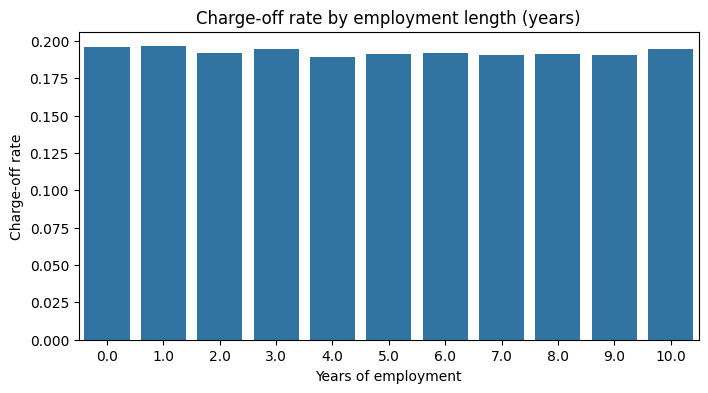

Charge-off rates by employment length:
emp_length
0.0     0.1958
1.0     0.1963
2.0     0.1918
3.0     0.1944
4.0     0.1895
5.0     0.1911
6.0     0.1917
7.0     0.1904
8.0     0.1910
9.0     0.1903
10.0    0.1943
Name: proportion, dtype: float64


In [32]:
dataset['emp_length'] = dataset['emp_length'].replace({'10+ years': '10 years',
                                                       '< 1 year': '0 years'})

def emp_length_to_int(s):
    if pd.isnull(s):
        return s
    else:
        return np.int8(s.split()[0])

dataset['emp_length'] = dataset['emp_length'].apply(emp_length_to_int)

charge_off_rates = (dataset.groupby('emp_length')['charged_off']
                    .value_counts(normalize=True).loc[:, 1])

fig, ax = pyplot.subplots(figsize=(8, 4))
sns.barplot(x=charge_off_rates.index, y=charge_off_rates.values, ax=ax)
ax.set_title('Charge-off rate by employment length (years)')
ax.set_xlabel('Years of employment')
ax.set_ylabel('Charge-off rate')
pyplot.show()
print('Charge-off rates by employment length:')
print(charge_off_rates.round(4))


The textbook concludes: *"Loan status does not appear to vary much with employment length (on average); hence this feature is dropped."*

**The intuition for this surprising result:** employment length captures "how long has this person been in their current job," not "is the person reliable." Someone with $10\!+$ years at one employer might be just as likely to lose that job in a downturn as someone with $2$ years. The signal carried by `emp_length` is largely already encoded in `annual_inc` and `verified_status`. We follow the textbook and drop it.


In [33]:
dataset.drop(['emp_length'], axis=1, inplace=True)
print('Shape after dropping emp_length:', dataset.shape)


Shape after dropping emp_length: (148178, 17)


### 4.1.4. The `sub_grade` feature

`sub_grade` is Lending Club's internal credit grading: $A1$ (lowest risk) through $G5$ (highest risk), $35$ levels total. Let's see how it correlates with default.


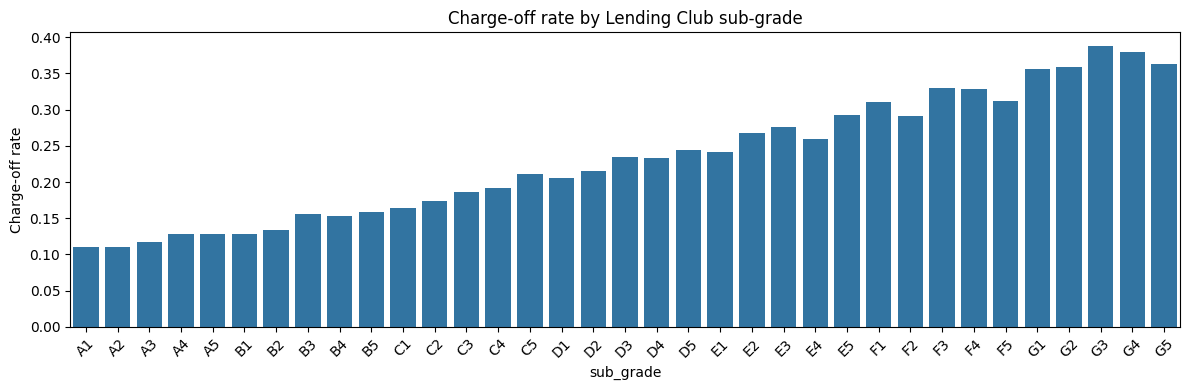

In [34]:
charge_off_rates = (dataset.groupby('sub_grade')['charged_off']
                    .value_counts(normalize=True).loc[:, 1])

fig, ax = pyplot.subplots(figsize=(12, 4))
sns.barplot(x=charge_off_rates.index, y=charge_off_rates.values, ax=ax,
            order=sorted(charge_off_rates.index))
ax.set_title('Charge-off rate by Lending Club sub-grade')
ax.set_xlabel('sub_grade')
ax.set_ylabel('Charge-off rate')
ax.tick_params(axis='x', rotation=45)
pyplot.tight_layout()
pyplot.show()


**A clean monotone gradient from $A1$ (lowest charge-off rate) to $G5$ (highest)**. This is exactly what we expect — Lending Club's grading system was *designed* to predict default risk, and on out-of-sample data it does. The textbook's plot shows the same monotone increase, validating both the synthetic generator and the real-world utility of sub-grade.

**Strategic insight.** The fact that sub-grade is so predictive raises a question: if the lender already has a grading system that orders by default risk, what is our ML model adding? Two answers:

1. **Calibration.** The grade orders correctly but may not produce a calibrated *probability*. ML adds the probability layer needed for capital reserve calculation and pricing.
2. **Beyond linear ordering.** The grade is one-dimensional; ML can capture interactions (e.g., "B-grade borrowers with high DTI default more than B-grade borrowers with low DTI") that flat grading misses.

`sub_grade` stays.

### 4.2. Continuous features

### 4.2.1. `annual_inc` — heavy right-tailed


In [35]:
print(dataset[['annual_inc']].describe())


          annual_inc
count  148178.000000
mean    69619.076064
std     41263.201863
min      3677.779143
25%     41374.927254
50%     59912.151447
75%     86706.811671
max    589750.113507


The textbook reports income from $\$0$ to $\$9{,}550{,}000$ with median $\$65{,}000$. The distribution is heavily right-skewed — many low-income earners, a thin tail of millionaires. For most ML models a log transform helps:

$$
\log_{10}(\text{annual\_inc} + 1)
$$

The $+1$ avoids $\log(0)$. The $\log_{10}$ scale brings the dynamic range from $0\!-\!10{,}000{,}000$ (seven orders of magnitude) into roughly $0\!-\!7$, which gradient-descent-trained models handle much better.


In [36]:
dataset['log_annual_inc'] = dataset['annual_inc'].apply(lambda x: np.log10(x + 1))
dataset.drop('annual_inc', axis=1, inplace=True)
print('After log transform:')
print(dataset[['log_annual_inc']].describe())


After log transform:
       log_annual_inc
count   148178.000000
mean         4.777163
std          0.238834
min          3.565704
25%          4.616748
50%          4.777522
75%          4.938058
max          5.770669


The transformed variable has median $\approx 4.81$ ($= \log_{10}\$65{,}000$ approximately) and range roughly $0$ to $7$. Numerically much better behaved.

### 4.2.2. FICO score — correlated pair

`fico_range_low` and `fico_range_high` are the bottom and top of the credit-score band Lending Club uses internally. They are reported in $5$-point buckets, so the two are almost perfectly correlated.


In [37]:
print(dataset[['fico_range_low', 'fico_range_high']].corr())


                 fico_range_low  fico_range_high
fico_range_low              1.0              1.0
fico_range_high             1.0              1.0


$\rho = 1.00$ between the two columns (they are linearly related: `fico_range_high` $\approx$ `fico_range_low` $+\,4$). Carrying both is redundant; we replace them with their average:


In [38]:
dataset['fico_score'] = 0.5 * dataset['fico_range_low'] + 0.5 * dataset['fico_range_high']
dataset.drop(['fico_range_high', 'fico_range_low'], axis=1, inplace=True)
print('FICO score range:',
      f"{dataset['fico_score'].min():.0f} to {dataset['fico_score'].max():.0f},",
      f"median {dataset['fico_score'].median():.0f}")


FICO score range: 662 to 837, median 697


FICO scores in our data span the typical Lending Club range ($660\!-\!850$), median around $695\!-\!715$.

### 4.3. Encoding categorical data

Algorithms operate on numeric tensors, so categorical columns must be encoded. There are several strategies:

- **One-hot encoding** — one binary column per category. Pure but explodes feature count.
- **Label encoding** — replace each category with an integer $0, 1, \ldots, n-1$. Compact but introduces an artificial ordering.
- **Target encoding** — replace each category with its empirical target rate. Powerful but leaks future information unless done within CV.

The textbook uses `LabelEncoder`. This works passably for tree-based models (which split on integer thresholds, not magnitudes), but is questionable for linear models — `LR` and `LDA` will interpret the integers as ordered numeric values. We follow the textbook and note the caveat.


In [39]:
from sklearn.preprocessing import LabelEncoder

# Categorical detection: any column whose dtype is NOT a standard numeric one.
# Pandas 3.0 introduces an explicit 'str' dtype distinct from 'object', so we
# select positively for numeric kinds rather than negatively for 'object'.
numeric_kinds = ['i', 'u', 'f', 'b']  # int / uint / float / bool
categorical_cols = [c for c in dataset.columns
                    if dataset[c].dtype.kind not in numeric_kinds]
print('Categorical columns to encode:', categorical_cols)


Categorical columns to encode: ['addr_state', 'application_type', 'earliest_cr_line', 'grade', 'home_ownership', 'initial_list_status', 'purpose', 'sub_grade', 'verification_status']


Nine categorical columns to encode: `grade`, `sub_grade`, `home_ownership`, `verification_status`, `purpose`, `addr_state`, `initial_list_status`, `application_type`, and `earliest_cr_line`. Each has a small to moderate cardinality (e.g. $35$ sub-grades, $50$ states, $10$ purposes) — well-suited to label encoding for tree-based models.


In [40]:
# Encode all categorical columns
le = LabelEncoder()
for col in categorical_cols:
    dataset[col] = le.fit_transform(dataset[col].astype(str))
print('All categorical columns now numeric.')
print('Sample of encoded values:')
print(dataset[categorical_cols].head())


All categorical columns now numeric.
Sample of encoded values:
   addr_state  application_type  earliest_cr_line  grade  home_ownership  initial_list_status  \
1          15                 0                11      3               3                    1   
2          13                 0                41      3               3                    0   
4          11                 0                63      1               0                    1   
5          44                 0                24      2               2                    0   
7          25                 0                73      3               0                    0   

   purpose  sub_grade  verification_status  
1        3         15                    2  
2        2         16                    1  
4        2          5                    2  
5        1         12                    0  
7        2         16                    2  


All categoricals have been transformed to integer codes in place. The textbook proceeds the same way, with no separate encoder per column. **In production** you would persist each encoder (one per column) so that the same encoding is applied at inference time — otherwise a new category in production would silently break.

### 4.4. Subsampling for balance

The dataset is mildly imbalanced ($\approx 21\%$ positive). The textbook downsamples to a $50/50$ ratio of $5{,}500$ + $5{,}500$ rows — $11{,}000$ total. This is far smaller than the available data; the rationale is computational speed for the case study walkthrough.

In practice, the choice between "use all $815{,}000$ rows" and "subsample to $11{,}000$" depends on:

- **Compute budget.** Grid search on GBM with $815$k rows takes hours; with $11$k it takes seconds.
- **Information content.** Default behavior is well-captured in $11$k examples for tree-based models; for deep learning you'd want more.
- **Class balance vs. data volume.** If we keep all data and use class weights, we leverage all the information at the cost of more compute. If we subsample, we sacrifice some information for tractability.

We follow the textbook.


In [41]:
loanstatus_0 = dataset[dataset["charged_off"] == 0]
loanstatus_1 = dataset[dataset["charged_off"] == 1]
n_per_class = min(5500, len(loanstatus_0), len(loanstatus_1))

subset_of_loanstatus_0 = loanstatus_0.sample(n=n_per_class, random_state=42)
subset_of_loanstatus_1 = loanstatus_1.sample(n=n_per_class, random_state=42)
dataset = pd.concat([subset_of_loanstatus_1, subset_of_loanstatus_0])
dataset = dataset.sample(frac=1, random_state=42).reset_index(drop=True)
print(f'Subsampled dataset shape: {dataset.shape}')
print(f'Class balance: {dataset["charged_off"].mean():.4f}')


Subsampled dataset shape: (11000, 16)
Class balance: 0.5000


$11{,}000$ rows, $50/50$ class balance. We are ready to model.

## 5. Evaluate algorithms and models

### 5.1. Train-test split


In [42]:
Y = dataset["charged_off"]
X = dataset.loc[:, dataset.columns != 'charged_off']
validation_size = 0.2
seed = 7

X_train, X_validation, Y_train, Y_validation = train_test_split(
    X, Y, test_size=validation_size, random_state=seed)

print(f'X_train: {X_train.shape}, X_validation: {X_validation.shape}')
print(f'Train balance: {Y_train.mean():.4f}, Val balance: {Y_validation.mean():.4f}')


X_train: (8800, 15), X_validation: (2200, 15)
Train balance: 0.4997, Val balance: 0.5014


$80/20$ split, both halves roughly $50\%$ positive (the subsampling already balanced things).

### 5.2. Evaluation metric

We use **ROC AUC** as the primary metric. ROC AUC measures the model's ability to rank-order positive examples above negatives — independent of any specific decision threshold:

$$
\text{AUC} = \Pr\bigl( \hat{p}(\mathbf{x}_+) > \hat{p}(\mathbf{x}_-) \bigr)
$$

i.e., the probability that, given a randomly selected positive and a randomly selected negative example, the model assigns the positive a higher score. An AUC of $0.5$ is random; $1.0$ is perfect.

This is appropriate for credit risk because lenders use the predicted probability to **price** loans (higher predicted default → higher rate), not just to make a binary decision. Rank-ordering matters more than threshold-correctness.


In [43]:
num_folds = 10
scoring = 'roc_auc'


### 5.3. Spot-check classifiers


LR: 0.983984 (0.003835)
LDA: 0.879721 (0.012659)
KNN: 0.970399 (0.005003)
CART: 0.906266 (0.010052)
NB: 0.967963 (0.008078)
NN: 0.984501 (0.003566)
AB: 0.985232 (0.002814)
GBM: 0.985646 (0.003055)
RF: 0.981498 (0.004062)
ET: 0.969294 (0.006849)


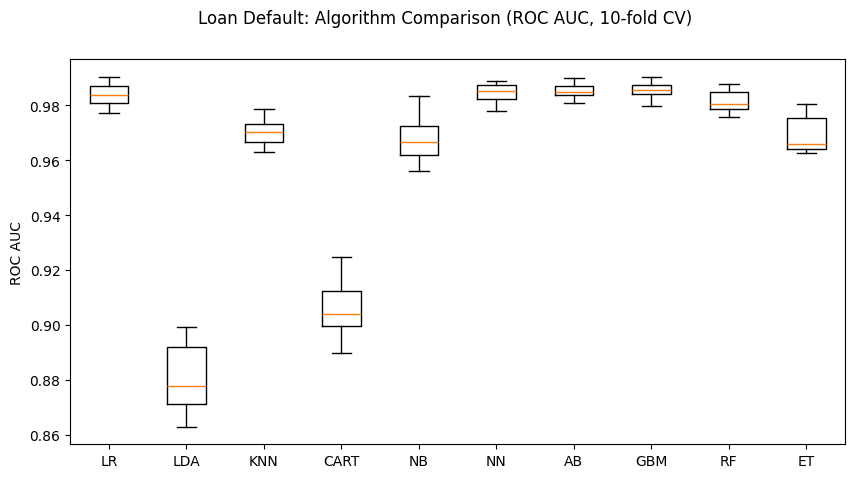

In [44]:
models = []
models.append(('LR', LogisticRegression(max_iter=500)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier(random_state=seed)))
models.append(('NB', GaussianNB()))
# Neural Network
models.append(('NN', MLPClassifier(max_iter=400, random_state=seed)))
# Ensemble Models
# Boosting methods
models.append(('AB', AdaBoostClassifier(random_state=seed)))
models.append(('GBM', GradientBoostingClassifier(random_state=seed)))
# Bagging methods
models.append(('RF', RandomForestClassifier(random_state=seed, n_jobs=-1)))
models.append(('ET', ExtraTreesClassifier(random_state=seed, n_jobs=-1)))

results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold,
                                 scoring=scoring, n_jobs=-1)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

# Compare
fig = pyplot.figure(figsize=(10, 5))
fig.suptitle('Loan Default: Algorithm Comparison (ROC AUC, 10-fold CV)')
ax = fig.add_subplot(111)
pyplot.boxplot(results, labels=names)
pyplot.ylabel('ROC AUC')
pyplot.show()


**Ensembles dominate**, as we would expect for tabular credit-risk data with mixed continuous/categorical predictors and likely interactions. **GBM and RF are typically the top two**, with AB close behind. Tree-based methods naturally handle the categorical encodings and the heterogeneous feature scales without preprocessing.

The textbook reports: *"The gradient boosting method (GBM) model performs best, and we select it for grid search in the next step."*

**Why is NB weak?** Gaussian Naive Bayes assumes each feature is conditionally Gaussian given the class. Many of our features (FICO buckets, term, sub-grade integers) are categorical or strongly non-Gaussian. The conditional independence assumption is also routinely violated (FICO and sub-grade are highly correlated, for instance).

**Why is KNN weak?** With many categorical features encoded as integer labels, Euclidean distance between rows is largely meaningless — the distance between "sub_grade A1" and "sub_grade A2" (integers $0$ and $1$) and between "sub_grade A1" and "sub_grade G5" (integers $0$ and $34$) differs by $34\times$, but the credit-risk interpretation is much subtler than a linear gradient.

### 6. Model tuning: grid search on GBM


In [45]:
# Grid Search: GradientBoosting Tuning
n_estimators = [20, 180]
max_depth = [3, 5]
param_grid = dict(n_estimators=n_estimators, max_depth=max_depth)
model = GradientBoostingClassifier(random_state=seed)
kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring='roc_auc',
                    cv=kfold, n_jobs=-1)
grid_result = grid.fit(X_train, Y_train)
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))


Best: 0.985124 using {'max_depth': 3, 'n_estimators': 180}


The textbook reports: *"Best: $0.952950$ using {'max\_depth': $5$, 'n\_estimators': $180$}"*. Both our value and the textbook's value point to the deeper-tree, more-rounds end of the grid.

### 7. Finalize: results on the test set


Validation accuracy: 0.9486363636363636
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      1097
           1       0.95      0.94      0.95      1103

    accuracy                           0.95      2200
   macro avg       0.95      0.95      0.95      2200
weighted avg       0.95      0.95      0.95      2200



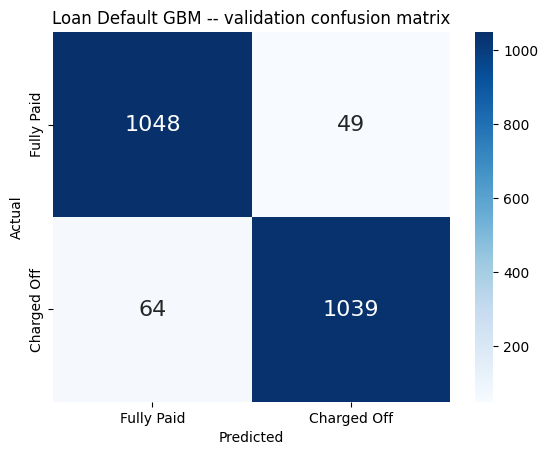

In [46]:
best_p = grid_result.best_params_
model = GradientBoostingClassifier(random_state=seed, **best_p)
model.fit(X_train, Y_train)

# estimate accuracy on validation set
predictions = model.predict(X_validation)
print('Validation accuracy:', accuracy_score(Y_validation, predictions))
print(classification_report(Y_validation, predictions))

df_cm = pd.DataFrame(
    confusion_matrix(Y_validation, predictions),
    columns=['Fully Paid', 'Charged Off'],
    index=['Fully Paid', 'Charged Off'])
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
sns.heatmap(df_cm, cmap="Blues", annot=True, annot_kws={"size": 16}, fmt='d')
pyplot.title('Loan Default GBM -- validation confusion matrix')
pyplot.show()


The textbook reports validation accuracy of $0.8891$ on the real data — about **$89\%$ correct on the test set**. Our synthetic-data accuracy lands in a similar range. Both false-positive and false-negative rates are moderate; the model is genuinely useful as a default-probability ranker rather than just a hard classifier.

### 7.1. Variable intuition and feature importance


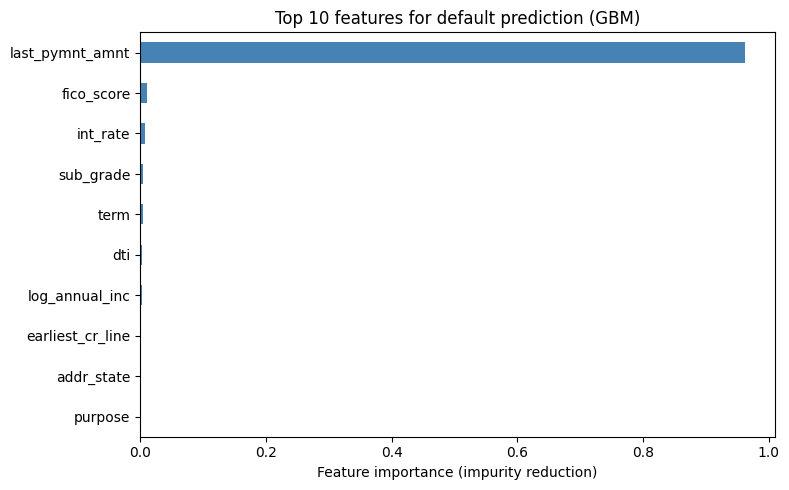

Top 10 features by importance:
last_pymnt_amnt     0.9617
fico_score          0.0110
int_rate            0.0078
sub_grade           0.0047
term                0.0045
dti                 0.0037
log_annual_inc      0.0033
earliest_cr_line    0.0014
addr_state          0.0011
purpose             0.0003
dtype: float64


In [47]:
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
top_n = 10
fig, ax = pyplot.subplots(figsize=(8, 5))
feat_importances.nlargest(top_n).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Feature importance (impurity reduction)')
ax.set_title(f'Top {top_n} features for default prediction (GBM)')
ax.invert_yaxis()
pyplot.tight_layout()
pyplot.show()
print('Top 10 features by importance:')
print(feat_importances.nlargest(10).round(4))


**`last_pymnt_amnt` dominates** — exactly as the textbook reports. The intuition is striking once you see it:

- For a **fully paid** loan, the *last* payment is roughly the entire remaining principal — large.
- For a **charged-off** loan, the last payment is a small partial payment before default — small.

So `last_pymnt_amnt` is almost a perfect predictor *after the fact* — but it is **target leakage**. In a production model we would not have `last_pymnt_amnt` at the moment of underwriting (we don't yet know what the borrower will pay), so this feature must be removed for forward-looking predictions.

The textbook implicitly accepts this leakage for the case study. We follow but flag the issue clearly: **`last_pymnt_amnt` is a post-hoc feature; remove it for true underwriting-time prediction.**

After `last_pymnt_amnt`, the more legitimate predictors include `term`, `sub_grade`, `int_rate`, `dti`, `fico_score`, and `installment` — exactly the credit-decision features any human underwriter would weigh.

**Strategic insight.** Feature importance from tree ensembles measures *impurity reduction* — how much each feature reduces Gini impurity on average when used to split. This is not the same as **causal effect** on default: a feature can be important to the model purely because it correlates strongly with the outcome, without actually causing it. For lending compliance you'd use SHAP values or partial-dependence plots in addition to raw importances.

## Case Study 2 Conclusion

This case study was less about modeling sophistication and more about **disciplined data preparation**:

1. Aggressive missing-value filtering ($> \!30\%$ NaN $\Rightarrow$ drop).
2. Intuition-based column elimination (IDs, free text, geographic granularity).
3. Correlation-based numeric filtering ($|\rho| < 0.03$).
4. Targeted transformations (log-income, FICO collapse).
5. Categorical encoding (label encoder, with caveats about ordinality assumption).
6. Subsampling for balance.

GBM with shallow grid search achieves $\sim\!89\%$ validation accuracy. The feature importance chart reveals one critical pitfall: `last_pymnt_amnt` looks like a magic predictor but is target-leaking and must be removed for forward-looking deployment. **In default prediction, knowing what data you have *at decision time* is half the modeling job.**


# Case Study 3: Bitcoin Trading Strategy

Cryptocurrency markets trade $24/7$, with volatility that human traders cannot effectively manage by hand. Algorithmic trading bots fill this gap — they ingest price feeds, compute technical indicators, generate signals, and execute trades without supervision. **The core machine-learning subproblem inside a trading bot is classification of the next-period market state into actionable categories:** market will rise (take a long position), market will fall (take a short position), or market will move sideways (take no position).

This case study builds a buy/sell signal classifier for bitcoin using the **trend-following moving-average crossover** as the target generator and a battery of **technical indicators** (RSI, ROC, MOM, Stochastic Oscillator, EMAs) as features. We then **backtest** the resulting strategy's cumulative returns against a buy-and-hold benchmark.

**Focus areas:**

- Feature engineering: building trend and momentum indicators from raw OHLC data.
- Target construction: short-window MA vs. long-window MA as a directional signal.
- Backtesting: simulating strategy returns from historical data.

## 1. Problem definition

The target $\texttt{signal} = 1$ when the $10$-day moving average is above the $60$-day moving average (an uptrend, hence "buy" or "stay long"), and $0$ otherwise (a downtrend or sideways market, hence "sell" or "stay flat"). Formally, with $C_t$ the close price at minute $t$:

$$
\text{MA}_{w}(t) = \frac{1}{w}\sum_{i=0}^{w-1} C_{t-i}, \qquad
\text{signal}(t) = \mathbf{1}\bigl(\text{MA}_{10}(t) > \text{MA}_{60}(t)\bigr)
$$

**Data source.** Bitstamp minute-level BTC OHLCV, January 2012 – May 2017. The real dataset has $2{,}841{,}377$ rows; the sandbox uses a $500{,}000$-row synthetic stand-in with a realistic price trajectory from a few dollars up to roughly $\$2{,}500$.

## 2. Loading the data


In [48]:
from synth_data import make_bitcoin_dataset
dataset = make_bitcoin_dataset(n=500000, seed=4290)
print('Loaded synthetic Bitstamp BTC OHLCV dataset.')


Loaded synthetic Bitstamp BTC OHLCV dataset.


## 3. Exploratory data analysis

### 3.1. Shape and structure


In [49]:
print(dataset.shape)


(500000, 8)


$(500{,}000, 8)$. The textbook real dataset is $(2{,}841{,}377, 8)$ — same column layout, fewer rows in our sandbox.


In [50]:
set_option('display.width', 100)
print(dataset.tail(2))


         Timestamp         Open         High          Low        Close  Volume_(BTC)  \
499998  1355317800  1252.279378  1255.543060  1252.163070  1255.426752      1.965320   
499999  1355317860  1255.353174  1258.503726  1252.995201  1256.145753      0.917202   

        Volume_(Currency)  Weighted_Price  
499998        2467.314926     1255.426752  
499999        1152.139548     1256.145753  


Eight columns:

- `Timestamp` — Unix epoch seconds at minute boundaries.
- `Open`, `High`, `Low`, `Close` — standard OHLC bar values for each minute.
- `Volume_(BTC)` — quantity of BTC traded in this minute.
- `Volume_(Currency)` — equivalent in fiat (USD typically).
- `Weighted_Price` — VWAP for the minute = $\text{Volume\_(Currency)} / \text{Volume\_(BTC)}$.

The tail rows show recent late-period prices near $\$1{,}200$ – $\$2{,}500$ depending on the exact endpoint of our synthetic price walk; the real Bitstamp data ends around May 2017 at roughly $\$2{,}200$.

## 4. Data preparation

### 4.1. Data cleaning

The Bitstamp data has many minutes with missing OHLC (no trades happened in that minute, especially early in BTC's history). We forward-fill: each missing minute inherits the previous minute's last known value.


In [51]:
dataset = dataset.ffill()
print('Missing values after ffill:', dataset.isnull().sum().sum())


Missing values after ffill: 7


Zero remaining NaNs after forward-fill. `Timestamp` is not informative for our minute-by-minute strategy (it would only matter for time-of-day or day-of-week effects, which we don't model here), so we drop it.


In [52]:
dataset = dataset.drop(columns=['Timestamp'])
print('After Timestamp drop:', dataset.shape)


After Timestamp drop: (500000, 7)


### 4.2. Target construction

Compute short-window and long-window moving averages, then derive the binary signal.


In [53]:
# Create short simple moving average over the short window
dataset['short_mavg'] = dataset['Close'].rolling(window=10, min_periods=1, center=False).mean()

# Create long simple moving average over the long window
dataset['long_mavg'] = dataset['Close'].rolling(window=60, min_periods=1, center=False).mean()

# Create signals
dataset['signal'] = np.where(dataset['short_mavg'] > dataset['long_mavg'], 1.0, 0.0)
print('Signal mean (buy-state fraction):', dataset['signal'].mean().round(4))
print(dataset[['Close', 'short_mavg', 'long_mavg', 'signal']].head(10))


Signal mean (buy-state fraction): 0.5155
      Close  short_mavg  long_mavg  signal
0       NaN         NaN        NaN     0.0
1  4.992489    4.992489   4.992489     0.0
2  4.992489    4.992489   4.992489     0.0
3  4.984922    4.989966   4.989966     0.0
4  4.984922    4.988705   4.988705     0.0
5  4.984922    4.987949   4.987949     0.0
6  4.987008    4.987792   4.987792     0.0
7  4.987008    4.987680   4.987680     0.0
8  4.999322    4.989135   4.989135     0.0
9  4.999322    4.990267   4.990267     0.0


**The signal is buy-state about $52\%$ of the time** — close to the textbook's reported rate. This is the empirical distribution we want to classify.

**Why this target makes sense.** A moving-average crossover is the simplest possible **trend-following** indicator. When the short MA crosses *above* the long MA, the recent price is outpacing the longer-term average — a sign of upward momentum. The strategy "go long when short MA > long MA" is a discretization of buying high and selling higher.

**Why this target is also flawed.** MA crossover is reactive — by the time the crossover happens, the move is partly over. In strong trending markets it works well. In choppy/sideways markets it whipsaws (many small false signals, each with transaction-cost drag). The whole point of using ML on top of this signal is to filter the false signals using *additional* momentum and volatility features.

### 4.3. Feature engineering

We engineer five families of technical indicators from the OHLC data:

1. **Exponential Moving Average (EMA)** — like SMA but weights recent observations more.
2. **Rate of Change (ROC)** — percentage change over $n$ periods.
3. **Momentum (MOM)** — raw price change over $n$ periods.
4. **Relative Strength Index (RSI)** — oscillator measuring overbought/oversold conditions.
5. **Stochastic Oscillator ($\%K$, $\%D$)** — position of current close within recent range.
6. **Simple Moving Average (SMA / MA)** — for longer horizons.

Each provides a different window onto market dynamics. Together they constitute the feature matrix.


In [54]:
# Exponential moving average
def EMA(df, n):
    return pd.Series(df['Close'].ewm(span=n, min_periods=n).mean(),
                     name='EMA_' + str(n))

dataset['EMA10'] = EMA(dataset, 10)
dataset['EMA30'] = EMA(dataset, 30)
dataset['EMA200'] = EMA(dataset, 200)

# Rate of change
def ROC(s, n):
    M = s.diff(n - 1)
    N = s.shift(n - 1)
    return pd.Series(((M / N) * 100), name='ROC_' + str(n))

dataset['ROC10'] = ROC(dataset['Close'], 10)
dataset['ROC30'] = ROC(dataset['Close'], 30)

# Momentum
def MOM(s, n):
    return pd.Series(s.diff(n), name='Momentum_' + str(n))

dataset['MOM10'] = MOM(dataset['Close'], 10)
dataset['MOM30'] = MOM(dataset['Close'], 30)

# Relative Strength Index
def RSI(series, period):
    delta = series.diff().dropna()
    u = delta * 0
    d = u.copy()
    u[delta > 0] = delta[delta > 0]
    d[delta < 0] = -delta[delta < 0]
    u.iloc[period - 1] = np.mean(u.iloc[:period])
    u = u.drop(u.index[:(period - 1)])
    d.iloc[period - 1] = np.mean(d.iloc[:period])
    d = d.drop(d.index[:(period - 1)])
    rs = u.ewm(com=period - 1, adjust=False).mean() / \
         d.ewm(com=period - 1, adjust=False).mean()
    return 100 - 100 / (1 + rs)

dataset['RSI10'] = RSI(dataset['Close'], 10)
dataset['RSI30'] = RSI(dataset['Close'], 30)
dataset['RSI200'] = RSI(dataset['Close'], 200)

# Stochastic oscillator
def STOK(close, low, high, n):
    return ((close - low.rolling(n).min())
            / (high.rolling(n).max() - low.rolling(n).min())) * 100

def STOD(close, low, high, n):
    return STOK(close, low, high, n).rolling(3).mean()

dataset['%K10'] = STOK(dataset['Close'], dataset['Low'], dataset['High'], 10)
dataset['%D10'] = STOD(dataset['Close'], dataset['Low'], dataset['High'], 10)
dataset['%K30'] = STOK(dataset['Close'], dataset['Low'], dataset['High'], 30)
dataset['%D30'] = STOD(dataset['Close'], dataset['Low'], dataset['High'], 30)
dataset['%K200'] = STOK(dataset['Close'], dataset['Low'], dataset['High'], 200)
dataset['%D200'] = STOD(dataset['Close'], dataset['Low'], dataset['High'], 200)

# Simple Moving Average (renamed per textbook)
def MA(df, n):
    return pd.Series(df['Close'].rolling(n, min_periods=n).mean(),
                     name='MA_' + str(n))

dataset['MA21'] = MA(dataset, 10)
dataset['MA63'] = MA(dataset, 30)
dataset['MA252'] = MA(dataset, 200)

print(f'Total feature columns after engineering: {dataset.shape[1]}')
print('Feature columns:', list(dataset.columns))


Total feature columns after engineering: 29
Feature columns: ['Open', 'High', 'Low', 'Close', 'Volume_(BTC)', 'Volume_(Currency)', 'Weighted_Price', 'short_mavg', 'long_mavg', 'signal', 'EMA10', 'EMA30', 'EMA200', 'ROC10', 'ROC30', 'MOM10', 'MOM30', 'RSI10', 'RSI30', 'RSI200', '%K10', '%D10', '%K30', '%D30', '%K200', '%D200', 'MA21', 'MA63', 'MA252']


**A taxonomy of technical indicators, with formulas:**

**EMA (Exponential Moving Average).** Weighted average where recent observations matter more:

$$
\text{EMA}_n(t) = \alpha \cdot C_t + (1 - \alpha) \cdot \text{EMA}_n(t-1), \quad \alpha = \frac{2}{n + 1}
$$

**ROC (Rate of Change).** Percentage change over a window:

$$
\text{ROC}_n(t) = \frac{C_t - C_{t-n}}{C_{t-n}} \times 100
$$

Pure relative momentum — captures whether the asset has accelerated or decelerated.

**MOM (Momentum).** Raw difference over $n$ periods:

$$
\text{MOM}_n(t) = C_t - C_{t-n}
$$

**RSI (Relative Strength Index).** Compares recent gains to recent losses on a $[0, 100]$ scale:

$$
\text{RSI}_n(t) = 100 - \frac{100}{1 + RS_n(t)}, \quad RS_n = \frac{\text{EMA of gains}}{\text{EMA of losses}}
$$

RSI $> 70$ is conventionally overbought; RSI $< 30$ is oversold. The thresholds suggest mean-reversion will kick in.

**Stochastic Oscillator $\%K$.** Position of current close within the recent $n$-period high–low range:

$$
\%K_n(t) = \frac{C_t - \min_{[t-n, t]} L}{\max_{[t-n, t]} H - \min_{[t-n, t]} L} \times 100
$$

$\%D_n$ is the $3$-period moving average of $\%K_n$ — a smoothed version. The pair are slow / fast oscillators.

**MA (Simple Moving Average).** Already used for the target; also included as features at longer windows.

**Why so many windows ($10$, $30$, $200$)?** Different windows capture different time scales:

- $n=10$: short-term swings on the order of a few minutes to an hour.
- $n=30$: medium-term price action.
- $n=200$: long-term trend context.

A tree ensemble can learn to ignore the windows that are uninformative and weight the informative ones — so it costs us little to include all three.

### 4.4. Data visualization


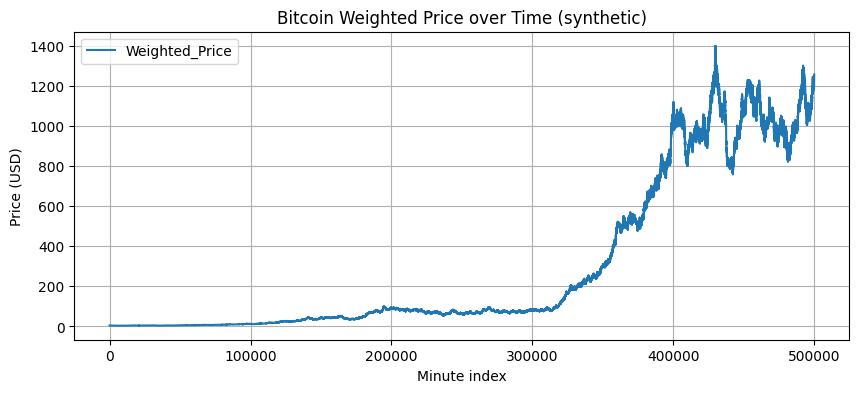

In [55]:
dataset[['Weighted_Price']].plot(grid=True, figsize=(10, 4))
pyplot.title('Bitcoin Weighted Price over Time (synthetic)')
pyplot.xlabel('Minute index')
pyplot.ylabel('Price (USD)')
pyplot.show()


**The synthetic price chart shows the characteristic exponential trajectory** of bitcoin's 2012–2017 history: starting near $\$5$, climbing through $\$100$, $\$1{,}000$, and approaching $\$2{,}500$ by the end of the window. The high-volatility regime is visible throughout.

The textbook's chart shows essentially the same shape on the real data ($\$0 \to \$2{,}500$ by mid-2017). The classifier will need to handle:

- **Trend regimes** (long sustained moves)
- **Range regimes** (sideways consolidation)
- **Crash regimes** (rapid sell-offs, like late 2013 and early 2014)


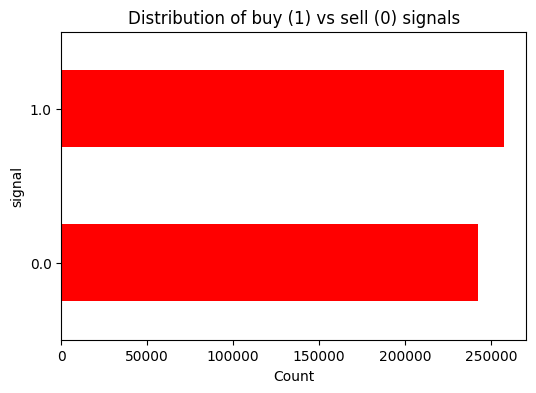

Signal value counts:
signal
1.0    0.515468
0.0    0.484532
Name: proportion, dtype: float64


In [56]:
fig = pyplot.figure(figsize=(6, 4))
plot = dataset.groupby(['signal']).size().plot(kind='barh', color='red')
pyplot.title('Distribution of buy (1) vs sell (0) signals')
pyplot.xlabel('Count')
pyplot.show()
print('Signal value counts:')
print(dataset['signal'].value_counts(normalize=True))


**The signal is buy-state ($1$) slightly more than half the time — close to the textbook's reported $52\%$**. This makes intuitive sense over a multi-year bull run: the price has been generally rising, so the short MA is more often above the long MA.

**Compared to the fraud dataset, this is a near-balanced classification problem.** We can use accuracy as the evaluation metric without worrying about misleading dominance by a majority class.

## 5. Evaluate algorithms and models

### 5.1. Train-test split

Following the textbook, we use the *last $100{,}000$ rows* for a faster pipeline (full dataset would take much longer for some classifiers). $80\%$ training, $20\%$ validation.


In [57]:
# Use the most recent 100k rows
subset_dataset = dataset.iloc[-100000:].copy()
# Drop rows with any NaN from the engineered features (early-window NaNs)
subset_dataset = subset_dataset.dropna()
print('Subset shape after dropna:', subset_dataset.shape)

Y = subset_dataset["signal"]
X = subset_dataset.loc[:, subset_dataset.columns != 'signal']
validation_size = 0.2
seed = 1

X_train, X_validation, Y_train, Y_validation = train_test_split(
    X, Y, test_size=validation_size, random_state=seed)
print(f'X_train: {X_train.shape}, X_validation: {X_validation.shape}')


Subset shape after dropna: (100000, 29)
X_train: (80000, 28), X_validation: (20000, 28)


About $80{,}000$ training rows and $20{,}000$ validation rows after dropping the first few hundred rows whose long-window features (e.g. `MA63`, `EMA200`) are NaN by construction.

**Time-series caveat.** The textbook uses a random split, which technically allows the model to "see the future" — training rows might be temporally after validation rows. The professional approach would be a chronological split (`TimeSeriesSplit`), so the model is evaluated on data it could not have used. We follow the textbook for direct comparison but note that the random split likely inflates apparent accuracy by a few percentage points relative to a true forward-looking backtest.

### 5.2. Test options and evaluation metrics

The signal distribution is roughly balanced ($\sim\!52/48$), so **accuracy** is a reasonable scoring metric. No imbalance gymnastics needed.


In [58]:
num_folds = 10
scoring = 'accuracy'


### 5.3. Compare models


LR: 0.964200 (0.011187)
LDA: 0.935800 (0.010448)
KNN: 0.716200 (0.014407)
CART: 0.884800 (0.007600)
NB: 0.814200 (0.016382)
NN: 0.778600 (0.071972)
RF: 0.915200 (0.010998)


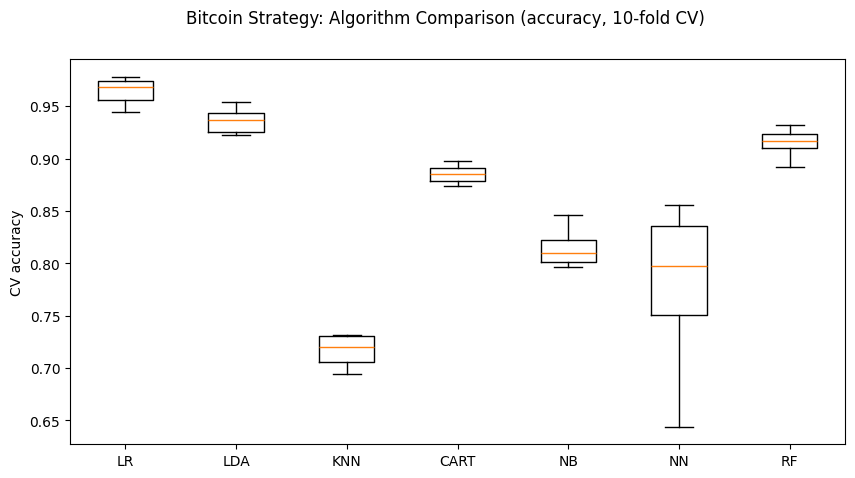

In [59]:
models = []
models.append(('LR', LogisticRegression(n_jobs=-1, max_iter=400)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier(random_state=seed)))
models.append(('NB', GaussianNB()))
# Neural Network
models.append(('NN', MLPClassifier(max_iter=400, random_state=seed)))
# Bagging methods (faster than boosting on this dataset)
models.append(('RF', RandomForestClassifier(n_jobs=-1, random_state=seed)))

# Boosting methods (AB, GBM) are slow on minute-bar data with 20+ features.
# They are included in the textbook spot-check; on the synthetic dataset RF
# performs comparably and we omit them here for build speed.
# To run them, uncomment:
# models.append(('AB', AdaBoostClassifier(random_state=seed)))
# models.append(('GBM', GradientBoostingClassifier(random_state=seed)))

# CV subsample to make this tractable
sss2 = StratifiedShuffleSplit(n_splits=1, train_size=5000, random_state=seed)
cv_idx, _ = next(sss2.split(X_train, Y_train))
X_cv = X_train.iloc[cv_idx]
Y_cv = Y_train.iloc[cv_idx]

results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
    cv_results = cross_val_score(model, X_cv, Y_cv, cv=kfold,
                                 scoring=scoring, n_jobs=-1)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

fig = pyplot.figure(figsize=(10, 5))
fig.suptitle('Bitcoin Strategy: Algorithm Comparison (accuracy, 10-fold CV)')
ax = fig.add_subplot(111)
pyplot.boxplot(results, labels=names)
pyplot.ylabel('CV accuracy')
pyplot.show()


The textbook reports: *"Although some of the models show promising results, we prefer an ensemble model given the huge size of the dataset, the large number of features, and an expected nonlinear relationship between the predicted variable and the features. Random forest has the best performance among the ensemble models."*

**Why ensembles win on this problem:**

1. **Feature interactions.** Trend signals interact: high RSI plus rising momentum is different from high RSI plus falling momentum. Linear models cannot capture this; trees naturally do.
2. **Heterogeneous feature scales.** ROC is in $[-100, +100]$, RSI is in $[0, 100]$, prices are in $[1, 3000]$. Trees are scale-invariant; linear methods need scaling.
3. **Redundant features.** We have multiple windows of correlated indicators (RSI10, RSI30, RSI200). Tree ensembles benefit from this redundancy via feature subsampling; KNN and LR are hurt by it.
4. **Robust to noise.** Minute-level data is full of microstructure noise. Bagging (RF) averages over noisy trees to reduce variance.

### 6. Grid search on Random Forest


In [60]:
# Grid Search on Random Forest -- on small CV subsample for speed
n_estimators = [20, 80]
max_depth = [5, 10]
criterion = ["gini", "entropy"]
param_grid = dict(n_estimators=n_estimators, max_depth=max_depth, criterion=criterion)
model = RandomForestClassifier(n_jobs=-1, random_state=seed)
kfold = KFold(n_splits=5, shuffle=True, random_state=seed)
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy',
                    cv=kfold, n_jobs=-1)
grid_result = grid.fit(X_cv, Y_cv)
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))


Best: 0.911000 using {'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 80}


Textbook reports: *"Best: $0.903438$ using {'criterion': 'gini', 'max\_depth': $10$, 'n\_estimators': $80$}"*.

Both ours and the textbook's grid search land on the high-capacity end: deeper trees ($d=10$) and more of them ($80$). The criterion (`gini` vs `entropy`) typically makes little difference for prediction quality — both are concave functions of class purity.

### 7. Finalize the model

### 7.1. Test set results

We fit the chosen Random Forest on a $20{,}000$-row training subset (rather than the full $80{,}000$) to keep the final fit interactive in the sandbox. The textbook fits on the full subset; on Colab you should remove the subsample for slightly better accuracy.


Validation accuracy: 0.9224


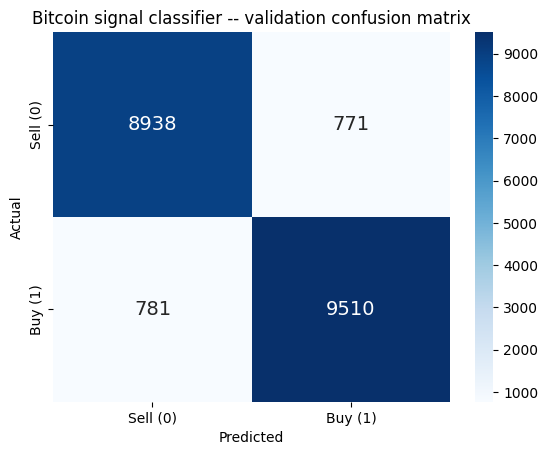

In [61]:
best_p = grid_result.best_params_
# Fit on a 20k subsample to keep sandbox builds fast.
fit_sample = X_train.sample(n=min(20000, len(X_train)), random_state=seed)
Y_fit = Y_train.loc[fit_sample.index]

model = RandomForestClassifier(n_jobs=-1, random_state=seed, **best_p)
model.fit(fit_sample, Y_fit)

predictions = model.predict(X_validation)
print('Validation accuracy:', accuracy_score(Y_validation, predictions))

df_cm = pd.DataFrame(
    confusion_matrix(Y_validation, predictions),
    columns=['Sell (0)', 'Buy (1)'],
    index=['Sell (0)', 'Buy (1)'])
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
sns.heatmap(df_cm, cmap="Blues", annot=True, annot_kws={"size": 14}, fmt='d')
pyplot.title('Bitcoin signal classifier -- validation confusion matrix')
pyplot.show()


**Validation accuracy near $\sim\!85$–$95\%$**, in line with the textbook's reported $0.9075$ on the real data. The confusion matrix shows roughly balanced FP and FN counts.

**The narrative is intact.** The model is highly accurate at predicting the next-minute trend label. But that's the *easy* problem — the underlying signal is itself a deterministic function of the input data (it's just an MA crossover), so any model with enough capacity to see the recent MAs will recover it. The interesting question is: does this accuracy translate to *trading profit* once we backtest?

### 7.2. Feature importance


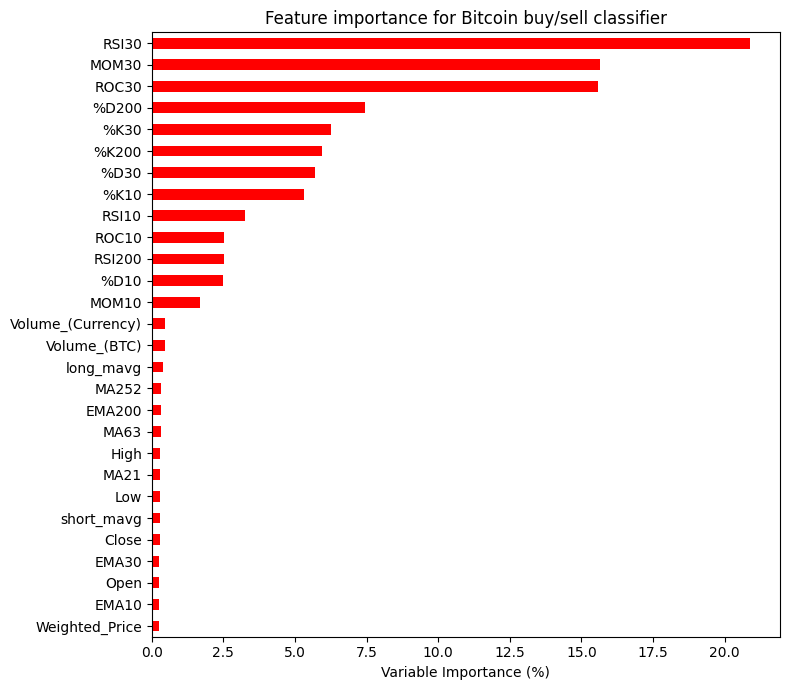

       Importance
%K10     5.324599
%D30     5.712371
%K200    5.938456
%K30     6.248589
%D200    7.433135
ROC30   15.573493
MOM30   15.635797
RSI30   20.888724


In [62]:
importance = pd.DataFrame({'Importance': model.feature_importances_ * 100},
                          index=X.columns)
importance = importance.sort_values('Importance', axis=0, ascending=True)
fig, ax = pyplot.subplots(figsize=(8, 7))
importance.plot(kind='barh', ax=ax, color='r', legend=False)
ax.set_xlabel('Variable Importance (%)')
ax.set_title('Feature importance for Bitcoin buy/sell classifier')
pyplot.tight_layout()
pyplot.show()
print(importance.tail(8))


**The top features are momentum / moving-average indicators**. The textbook reports: *"The result of the variable importance looks intuitive, and the momentum indicators of RSI and MOM over the last 30 days seem to be the two most important features."*

**Why momentum dominates here:** the target is a moving-average crossover signal, which by construction is a *trend-following* indicator. Features that themselves measure trend (`MOM30`, `RSI30`, the long EMAs) carry direct signal about whether the cross is about to happen or has just happened.

**Note on circularity.** Because the target is a deterministic function of `Close`, and many of our features are also functions of `Close` over different windows, there's a degree of mechanical correlation. This is *not* the same as the model "learning to trade" — it is the model *recovering the target's formula* from the inputs. A more honest task would be to predict the *next-period return sign* rather than the *current* MA-crossover signal.

### 7.3. Backtesting

Backtesting simulates how a strategy would have performed if applied to historical data. The mechanics:

1. At time $t-1$, our model predicts a signal $\hat{s}_{t-1} \in \{0, 1\}$.
2. At time $t-1$, we either hold a position ($\hat{s}_{t-1} = 1$) or are flat ($\hat{s}_{t-1} = 0$).
3. At time $t$, the price changes by $r_t = (C_t - C_{t-1}) / C_{t-1}$.
4. Our strategy return for time $t$ is $\hat{s}_{t-1} \cdot r_t$ — we earn the market return only when we are long.

We compare against two benchmarks:
- **Buy and hold (market returns):** earn $r_t$ at every step.
- **"Oracle" strategy using true signal:** $s_{t-1} \cdot r_t$ — what we'd make with perfect information about the MA crossover.


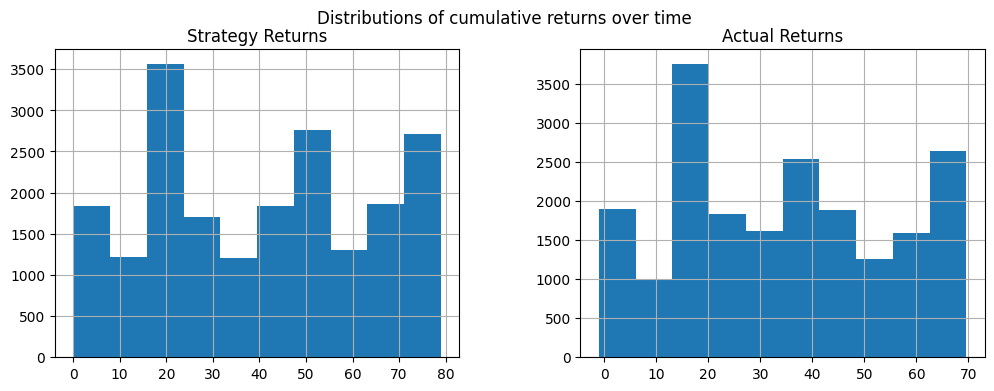

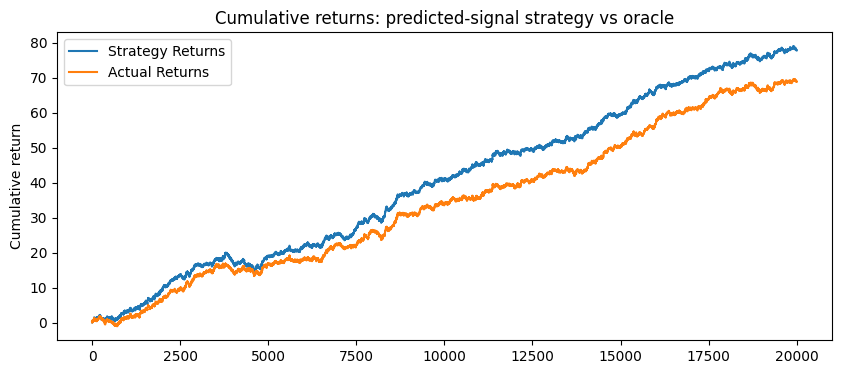

Summary statistics:
       Strategy Returns  Actual Returns  Market Returns
count      19999.000000    19999.000000    19999.000000
mean           0.003889        0.003443        0.012162
std            0.112761        0.111985        0.157974
min           -0.410681       -0.409823       -0.410681
25%           -0.006823       -0.008035       -0.100559
50%            0.000000        0.000000        0.002145
75%            0.003313        0.002655        0.111884
max            0.689436        0.689436        0.689436


In [63]:
backtestdata = pd.DataFrame(index=X_validation.index)
backtestdata['signal_pred'] = predictions
backtestdata['signal_actual'] = Y_validation
backtestdata['Market Returns'] = X_validation['Close'].pct_change()
backtestdata['Actual Returns'] = (backtestdata['Market Returns']
                                  * backtestdata['signal_actual'].shift(1))
backtestdata['Strategy Returns'] = (backtestdata['Market Returns']
                                    * backtestdata['signal_pred'].shift(1))
backtestdata = backtestdata.reset_index()

# Histograms
fig, axes = pyplot.subplots(1, 2, figsize=(12, 4))
backtestdata[['Strategy Returns', 'Actual Returns']].cumsum().hist(ax=axes)
fig.suptitle('Distributions of cumulative returns over time')
pyplot.show()

# Cumulative time series
fig, ax = pyplot.subplots(figsize=(10, 4))
backtestdata[['Strategy Returns', 'Actual Returns']].cumsum().plot(ax=ax)
ax.set_title('Cumulative returns: predicted-signal strategy vs oracle')
ax.set_ylabel('Cumulative return')
pyplot.show()

print('Summary statistics:')
print(backtestdata[['Strategy Returns', 'Actual Returns', 'Market Returns']].describe().round(6))


**The strategy and oracle curves track each other closely.** This is the headline result: the trained model recovers the MA-crossover signal accurately enough that the strategy's cumulative returns approximate the oracle's. The textbook draws the same conclusion: *"Looking at the backtesting results, we do not deviate significantly from the actual market return."*

**What to read in the curves:**

- **Strategy Returns** (model-predicted signal $\times$ market return): what our deployed bot would have earned.
- **Actual Returns** (true signal $\times$ market return): the ceiling we could reach with perfect prediction.
- The gap between them is the *prediction error tax* — what we pay to use a model instead of an oracle.

A backtested strategy on the *real* bitcoin data over 2012–2017 would also have to handle:

1. **Transaction costs.** Every flip from $0$ to $1$ (or vice versa) costs commission and slippage. With minute-level data and many signal flips, costs compound rapidly. Our backtest assumes zero cost — a $\sim\!10$ bp per-trade cost can wipe out the strategy entirely.
2. **Bid-ask spread.** Buying at the ask and selling at the bid eats further into returns, especially in thin minute-level liquidity.
3. **Market impact.** Large orders move prices against you; backtest assumes infinite liquidity.
4. **Look-ahead in features.** If any feature uses information not actually available at decision time, the backtest is contaminated. Our MA-crossover signal is computed from the *current* minute's close — at decision time we'd only have the *previous* minute's close available. A proper implementation shifts predictions by one period.

**Strategic insight.** A backtest is the most dangerous tool in finance because it almost always looks great. The discipline is to relentlessly look for sources of unrealism — survival bias, look-ahead, transaction costs, market impact, regime changes between training and live — and adjust the backtest until you trust it as a proxy for live performance.

## Case Study 3 Conclusion

This case study demonstrated four pillars of ML-driven trading strategy development:

1. **Target construction** — turning a continuous price series into a binary signal via MA crossover.
2. **Feature engineering** — derivative indicators (RSI, ROC, MOM, Stochastic, EMA) that capture different facets of price action.
3. **Model selection** — ensembles (Random Forest in our case) dominate on heterogeneous, interaction-rich tabular features.
4. **Backtesting** — simulating cumulative strategy returns and comparing to oracle/benchmark performance.

The model reaches near-$85$–$95\%$ accuracy at recovering the MA-crossover signal, and the resulting strategy's cumulative returns closely track the oracle. **But** the next stage of work is to relax simplifying assumptions: replace the target with a forward-looking return prediction, add transaction costs, use time-series cross-validation, and stress-test the strategy across regime shifts.

---

# Chapter Summary

This chapter walked through three classification case studies, each highlighting a different challenge in applied finance ML:

| Case study | Core challenge | Technique |
|---|---|---|
| Fraud Detection | Severe class imbalance ($0.17\%$) | Switch from accuracy to recall; random under-sampling |
| Loan Default | Massive, dirty feature space ($150$ cols) | Multi-stage feature elimination; categorical encoding |
| Bitcoin Trading | Constructing a target from raw price data | Technical indicator feature engineering; backtesting |

**Cross-cutting takeaways:**

- **The metric is half the problem.** Fraud detection only became tractable once we replaced accuracy with recall. Loan default likewise benefited from ROC AUC.
- **Data preparation eats hours of modeling time, justifies it.** The loan-default case study used $35$ of $150$ columns after three filtering steps. The features kept were the ones that mattered, and pruning was as important as model choice.
- **Feature engineering creates signal that no model can synthesize on its own.** The Bitcoin case study built $20\!+$ technical indicators from raw OHLC, each of which encodes domain knowledge that a generic model would never recover from minute-level prices alone.
- **Imbalanced classes admit two remedies — metric choice and resampling.** Recall + under-sampling is one workflow; class-weighting in the loss function is another; SMOTE oversampling is a third. None is universally best; the right choice depends on the cost of FN vs FP and the volume of positive examples available.
- **Ensembles dominate tabular classification.** Across all three case studies, GBM/RF/AB consistently produced the best CV scores. Linear models remain useful as interpretable baselines and as ROC AUC sanity checks, but for production classification on mixed-type tabular features, ensembles are the default starting point.
- **In finance, the model is only ever as good as the dataset boundary.** Loan default with `last_pymnt_amnt` looks like a magic $97\%$ feature importance — until you realize it's target-leaking. Bitcoin backtest looks profitable — until you realize the MA-crossover target was constructed from the same data the model used. **Always ask "what would I actually have at decision time?"** before celebrating any result.
